In [ ]:
# txt to excel
import pandas as pd
msp_wo_ts_path = "/OOD_Detection_15_transformation_rules-main/OOD_Detection-main/dataset_split/msp_wo_ts_index.txt"
msp_ts_path = "/OOD_Detection_15_transformation_rules-main/OOD_Detection-main/dataset_split/dataset_split/msp_ts_index.txt"

with open(msp_wo_ts_path, 'r') as file:
    msp_wo_ts_index = file.read().splitlines()

with open(msp_ts_path, 'r') as file:
    msp_ts_index = file.read().splitlines()
    
df = pd.DataFrame({
'Column1': msp_wo_ts_index,
'Column2': msp_ts_index
})

df.columns = ['msp_wo_ts_index', 'msp_ts_index']

output_file_path = '/home/hjy/Rationale_Extraction_using_Diffmask-main/Rationale_Extraction_using_Diffmask-main/dataset_split/msp_index_all.xlsx'

df.to_excel(output_file_path, index=False)

In [ ]:
import pandas as pd

data = pd.read_csv("/home/hjy/ood_detection/datasets/sci_chatgpt/test_data/500_snli_3label.txt", 
                   sep="\t", 
                   encoding='utf-8',
                   names=['원본레이블', '전제문장', '가설문장'],
                   index_col=False)

data.to_excel("/home/hjy/ood_detection/ood/TS/ts_100000_before_sort.xlsx", index=False, startrow=0, startcol=3, sheet_name='Sheet1')

In [ ]:
import pandas as pd
from openpyxl import load_workbook

# 인덱스 생성 [0][0] - [7][63]
excel_filename = "/OOD_Detection_15_transformation_rules-main/OOD_Detection-main/ood/TS/ts_100000_before_sort.xlsx"
sheet_name = 'Sheet1'
start_row=2
start_col=1

index = []
for i in range(0, 8):
    for j in range(0, 64):
        index.append("[" + str(i) + "][" + str(j) + "]")
index_df = pd.DataFrame(index, columns=['인덱스'])

book = load_workbook(excel_filename)
sheet = book[sheet_name] if sheet_name in book.sheetnames else book.create_sheet(sheet_name)
sheet.cell(row=start_row-1, column=start_col, value=index_df.columns[0])

for index, row in enumerate(index_df.itertuples(), start=start_row):
    sheet.cell(row=index, column=start_col, value=row.인덱스)

book.save(excel_filename)

In [ ]:
import pandas as pd
from openpyxl import load_workbook

# 임계값 텐서순으로 500개 나열
text_file = "/OOD_Detection_15_transformation_rules-main/OOD_Detection-main/dataset_split/ood/TS/TS_100000.txt"
excel_filename = "/OOD_Detection_15_transformation_rules-main/OOD_Detection-main/dataset_split/ood/TS/ts_100000_before_sort.xlsx"
sheet_name = 'Sheet1'
start_row=2
start_col=2 # 동일시트 특정 행,열에 추가

msp_score = pd.read_csv(text_file, sep="\n", header=None, names=['MSP_score'])
msp_score_df = pd.DataFrame(msp_score)
# print(msp_score_df.tail())

book = load_workbook(excel_filename)
sheet = book[sheet_name] if sheet_name in book.sheetnames else book.create_sheet(sheet_name)
sheet.cell(row=start_row-1, column=start_col, value='MSP_score')

for index, row in enumerate(msp_score_df.itertuples(), start=start_row):
    sheet.cell(row=index, column=start_col, value=row.MSP_score)

book.save(excel_filename)

In [ ]:
import pandas as pd
from openpyxl import load_workbook

# 분류된규칙 텐서순으로 500개 나열
text_file = "OOD_Detection_15_transformation_rules-main/OOD_Detection-main/dataset_split/ood/TS/TS_100000.txt"
excel_filename = "OOD_Detection_15_transformation_rules-main/OOD_Detection-main/dataset_split/ood/TS/ts_100000_before_sort.xlsx"
sheet_name = 'Sheet1'
start_row=2
start_col=3 # 동일시트 특정 행,열에 추가

predict_label = pd.read_csv(text_file, sep="\n", header=None, names=['분류된규칙'])
predict_label_df = pd.DataFrame(predict_label)
# print(msp_score_df.tail())

book = load_workbook(excel_filename)
sheet = book[sheet_name] if sheet_name in book.sheetnames else book.create_sheet(sheet_name)
sheet.cell(row=start_row-1, column=start_col, value='분류된규칙')

for index, row in enumerate(predict_label_df.itertuples(), start=start_row):
    sheet.cell(row=index, column=start_col, value=row.분류된규칙)

book.save(excel_filename)

In [ ]:
import pandas as pd

df_before_sort = pd.read_excel("OOD_Detection_15_transformation_rules-main/OOD_Detection-main/dataset_split/ood/TS/ts_100000_before_sort.xlsx")
df_copy = df_before_sort.copy()
df_after_sort = df_copy.sort_values(by='MSP_score') # 임계값 작은것 기준으로 정렬
ood_label = df_after_sort.copy()
ood_label.insert(3, '분류된레이블', None)
for idx, row in ood_label.iterrows():
    if 0 <= row['분류된규칙'] <= 4:
        ood_label.at[idx, '분류된레이블'] = 'entailment'
    elif 5 <= row['분류된규칙'] <= 11:
        ood_label.at[idx, '분류된레이블'] = 'contradiction'
    else:
        ood_label.at[idx, '분류된레이블'] = 'neutral'
ood_label_copy = ood_label.copy()
label_mapping = { 
                 0: 'HS',
                 1: 'PS', 
                 2: 'COUNT', 
                 3: 'PA', 
                 4: 'ES', 
                 5: 'CW_adj', 
                 6: 'CW_noun',
                 7: 'CV',
                 8: 'NS', 
                 9: 'SOS', 
                 10: 'IH', 
                 11: 'NI', 
                 12: 'AM', 
                 13: 'CON', 
                 14: 'SSNCV'}
ood_label_copy.insert(3, '규칙명', None)
for idx, row in ood_label_copy.iterrows():
    rule = row['분류된규칙']
    if rule in label_mapping:
        ood_label_copy.at[idx, '규칙명'] = label_mapping[rule]
    else:
        ood_label_copy.at[idx, '규칙명'] = 'Other'
ood_detect = ood_label_copy.copy()

ood_detect = ood_detect.dropna()
ood_detect['분류된규칙'] = ood_detect['분류된규칙'].astype(int).astype(str)
ood_detect

In [ ]:
import pandas as pd
# ood_detect = ood_detect.drop('레이블정답', axis=1)
# ood_detect = ood_detect.drop('규칙정답', axis=1)
# ood_detect = ood_detect.drop('OOD 여부', axis=1)

columns_to_add = ['레이블정답', '규칙정답', 'OOD 여부']
for col in columns_to_add:
    if col not in ood_detect.columns:
        ood_detect[col] = None

ood_detect['레이블정답'] = ood_detect.apply(lambda row: 'O' if row['분류된레이블'] == row['원본레이블'] else 'X', axis=1)
ood_detect['규칙정답'] = ood_detect.apply(lambda row: 'X' if row['분류된레이블'] != row['원본레이블'] else None, axis=1)
ood_detect['OOD 여부'] = ood_detect.apply(lambda row: 'O' if row['레이블정답'] == 'X' or row['규칙정답'] == 'X' else None, axis=1)
ood_detect

ood_detect.to_excel('OOD_Detection_15_transformation_rules-main/OOD_Detection-main/dataset_split/ood/TS/ts_100000_after_sort.xlsx')


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, roc_auc_score
import numpy as np

## original 에 대해
# after_sort_original = pd.read_excel("OOD_Detection_15_transformation_rules-main/OOD_Detection-main/dataset_split/ood/after_sort_original.xlsx")
# roc_curve_data = after_sort_original.copy()
# roc_curve_data = roc_curve_data.sort_values(by=['MSP_score'], ascending=False)
# roc_curve_data['OOD_roc_label'] = roc_curve_data.apply(lambda row: 0 if row['OOD 여부'] == 'O' else 1, axis=1) # 0.67
# roc_curve_data['OOD_roc_label'] = roc_curve_data.apply(lambda row: 1 if row['OOD 여부'] == 'O' else 0, axis=1) # 0.33
# roc_curve_data
# list_from_roc_label = roc_curve_data['OOD_roc_label'].tolist()
# list_from_score = roc_curve_data['MSP_score'].tolist()
# print(list_from_roc_label)
# print(list_from_score)
# print(roc_auc_score(list_from_roc_label, list_from_score))

# fpr, tpr, thresholds = roc_curve(list_from_roc_label, list_from_score)
# roc_auc = auc(fpr, tpr)

# plt.figure()
# plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
# plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='X=Y')
# plt.xlim([0.0, 1.0])
# plt.ylim([0.0, 1.0])
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# # plt.title('Receiver Operating Characteristic')
# plt.title('ROC Curve')
# plt.legend(loc="lower right")
# plt.show()

# # 특정 TPR 값에서 FPR 찾기
# target_tpr = 0.95
# closest_tpr_index = np.argmin(np.abs(tpr - target_tpr))
# fpr_at_target_tpr = fpr[closest_tpr_index]
# print(f"FPR at TPR {target_tpr}: {fpr_at_target_tpr}")


## goldset 에 대해
goldset_original = pd.read_excel("/OOD_Detection_15_transformation_rules-main/OOD_Detection-main/dataset_split/ood/GOLDSET.xlsx")
gs_roc_curve_data = goldset_original.copy()
gs_roc_curve_data = gs_roc_curve_data.sort_values(by=['MSP_score'], ascending=False)
gs_roc_curve_data['OOD_roc_label'] = gs_roc_curve_data.apply(lambda row: 0 if row['OOD 여부'] == 'O' else 1, axis=1) # 0.64
# gs_roc_curve_data['OOD_roc_label'] = gs_roc_curve_data.apply(lambda row: 1 if row['OOD 여부'] == 'O' else 0, axis=1) # 0.35
# gs_roc_curve_data

gs_list_from_roc_label = gs_roc_curve_data['OOD_roc_label'].tolist()
gs_list_from_score = gs_roc_curve_data['MSP_score'].tolist()
# print(gs_list_from_roc_label)
# print(gs_list_from_score)
# print(roc_auc_score(gs_list_from_roc_label, gs_list_from_score))


gs_fpr, gs_tpr, gs_thresholds = roc_curve(gs_list_from_roc_label, gs_list_from_score)
gs_roc_auc = auc(gs_fpr, gs_tpr)

plt.figure()
plt.plot(gs_fpr, gs_tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % gs_roc_auc)
# plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='X=Y')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
# plt.title('Receiver Operating Characteristic')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()

# 특정 TPR 값에서 FPR 찾기
gs_target_tpr = 0.95
gs_closest_tpr_index = np.argmin(np.abs(gs_tpr - gs_target_tpr))
gs_fpr_at_target_tpr = gs_fpr[gs_closest_tpr_index]
print(f"FPR at TPR {gs_target_tpr}: {gs_fpr_at_target_tpr}")


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, roc_auc_score
import numpy as np

ts_after_sort_original = pd.read_excel("OOD_Detection_15_transformation_rules-main/OOD_Detection-main/dataset_split/ood/GOLDSET기준_TS적용후.xlsx")
ts_roc_curve_data = ts_after_sort_original.copy()
ts_roc_curve_data = ts_roc_curve_data.sort_values(by=['MSP_score'], ascending=False)
ts_roc_curve_data['OOD_roc_label'] = ts_roc_curve_data.apply(lambda row: 0 if row['OOD 여부'] == 'O' else 1, axis=1) # 0.67
# ts_roc_curve_data['OOD_roc_label'] = ts_roc_curve_data.apply(lambda row: 1 if row['OOD 여부'] == 'O' else 0, axis=1) # 0.32
# ts_roc_curve_data

ts_list_from_roc_label = ts_roc_curve_data['OOD_roc_label'].tolist()
ts_list_from_score = ts_roc_curve_data['MSP_score'].tolist()
# print(ts_list_from_roc_label)
# print(ts_list_from_score)
# print(roc_auc_score(ts_list_from_roc_label, ts_list_from_score))

ts_fpr, ts_tpr, ts_thresholds = roc_curve(ts_list_from_roc_label, ts_list_from_score)
ts_roc_auc = auc(ts_fpr, ts_tpr)

plt.figure()
plt.plot(ts_fpr, ts_tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % ts_roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
# plt.title('Receiver Operating Characteristic')
plt.title('ROC Curve (Temperature Scaling)')
plt.legend(loc="lower right")
plt.show()

# 특정 TPR 값에서 FPR 찾기
ts_target_tpr = 0.95
ts_closest_tpr_index = np.argmin(np.abs(ts_tpr - ts_target_tpr))
ts_fpr_at_target_tpr = ts_fpr[ts_closest_tpr_index]
print(f"FPR at TPR {ts_target_tpr}: {ts_fpr_at_target_tpr}")


In [ ]:
# 3개의 ROC Curve 하나로 합치기

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, roc_auc_score
import numpy as np

# 첫 번째 데이터셋 로드 및 처리 # GOLDSET(MSP)
goldset_original = pd.read_excel("OOD_Detection_15_transformation_rules-main/OOD_Detection-main/ood/GOLDSET.xlsx")
gs_roc_curve_data = goldset_original.copy()
gs_roc_curve_data = gs_roc_curve_data.sort_values(by=['MSP_score'], ascending=False)
gs_roc_curve_data['OOD_roc_label'] = gs_roc_curve_data.apply(lambda row: 0 if row['OOD 여부'] == 'O' else 1, axis=1)
gs_list_from_roc_label = gs_roc_curve_data['OOD_roc_label'].tolist()
gs_list_from_score = gs_roc_curve_data['MSP_score'].tolist()

# 두 번째 데이터셋 로드 및 처리 # MSP + TS(T=1000)
ts_after_sort_original = pd.read_excel("OOD_Detection_15_transformation_rules-main/OOD_Detection-main/ood/GOLDSET기준_TS적용후.xlsx")
ts_roc_curve_data = ts_after_sort_original.copy()
ts_roc_curve_data = ts_roc_curve_data.sort_values(by=['MSP_score'], ascending=False)
ts_roc_curve_data['OOD_roc_label'] = ts_roc_curve_data.apply(lambda row: 0 if row['OOD 여부'] == 'O' else 1, axis=1)
ts_list_from_roc_label = ts_roc_curve_data['OOD_roc_label'].tolist()
ts_list_from_score = ts_roc_curve_data['MSP_score'].tolist()

# 세 번째 데이터셋 로드 및 처리 # Dropout Bayesian Approximation
dropout_original = pd.read_excel("OOD_Detection_15_transformation_rules-main/OOD_Detection-main/ood/dropout(0.1)_total100_notsort.xlsx")
dropout_data = dropout_original.copy()
dropout_data = dropout_data.sort_values(by=['신뢰도'], ascending=False)
dropout_data['OOD_roc_label'] = dropout_data.apply(lambda row: 0 if row['OOD 여부'] == 'O' else 1, axis=1)
dropout_label = dropout_data['OOD_roc_label'].tolist()
dropout_score = dropout_data['신뢰도'].tolist()

# 네 번째 데이터셋 로드 및 처리 # MSP + TS + Perturbation # 임시 outputs1
perturbation_original = pd.read_excel("OOD_Detection_15_transformation_rules-main/OOD_Detection-main/ood/perturbation/perturbation_output2.xlsx")
# perturbation_original = pd.read_excel("OOD_Detection_15_transformation_rules-main/OOD_Detection-main/ood/perturbation/perturbation_output1.xlsx")
perturbation_data = perturbation_original.copy()
perturbation_data = perturbation_data.sort_values(by=['values'], ascending=False)
perturbation_data['OOD_roc_label'] = perturbation_data.apply(lambda row: 0 if row['OOD 여부'] == 'O' else 1, axis=1)
# perturbation_data['OOD_roc_label'] = perturbation_data.apply(lambda row: 0 if row['OOD_TEST'] == 'O' else 1, axis=1)
perturbation_label = perturbation_data['OOD_roc_label'].tolist()
perturbation_score = perturbation_data['values'].tolist()

# ROC Curve 계산
gs_fpr, gs_tpr, _ = roc_curve(gs_list_from_roc_label, gs_list_from_score)
ts_fpr, ts_tpr, _ = roc_curve(ts_list_from_roc_label, ts_list_from_score)
do_fpr, do_tpr, _ = roc_curve(dropout_label, dropout_score)
per_fpr, per_tpr, _ = roc_curve(perturbation_label, perturbation_score)
gs_roc_auc = auc(gs_fpr, gs_tpr)
ts_roc_auc = auc(ts_fpr, ts_tpr)
do_roc_auc = auc(do_fpr, do_tpr)
per_roc_auc = auc(per_fpr, per_tpr)


# ROC Curve 그리기
plt.figure()
plt.plot(gs_fpr, gs_tpr, color='royalblue', lw=2, label='MSP w/o T.S= %0.4f' % gs_roc_auc)
plt.plot(ts_fpr, ts_tpr, color='lightcoral', lw=2, label='MSP + TS = %0.4f' % ts_roc_auc)
plt.plot(do_fpr, do_tpr, color='limegreen', lw=2, label='DROPOUT = %0.4f' % do_roc_auc)
plt.plot(per_fpr, per_tpr, color='gold', lw=2, label='MSP + TS + Perturbation = %0.4f' % per_roc_auc)
plt.plot([0, 1], [0, 1], color='dimgrey', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Comparison of ROC Curves')
plt.legend(loc="lower right")
plt.show()


In [ ]:
# T에 따른 그래프 그려보기(10, 100, 10000, 100000)

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, roc_auc_score
import numpy as np

# 첫 번째 데이터셋 로드 및 처리
goldset_original = pd.read_excel("OOD_Detection_15_transformation_rules-main/OOD_Detection-main/ood/GOLDSET.xlsx")
gs_roc_curve_data = goldset_original.copy()
gs_roc_curve_data = gs_roc_curve_data.sort_values(by=['MSP_score'], ascending=False)
gs_roc_curve_data['OOD_roc_label'] = gs_roc_curve_data.apply(lambda row: 0 if row['OOD 여부'] == 'O' else 1, axis=1)
gs_list_from_roc_label = gs_roc_curve_data['OOD_roc_label'].tolist()
gs_list_from_score = gs_roc_curve_data['MSP_score'].tolist()

# 두 번째 데이터셋 로드 및 처리(T=1000)
ts_after_sort_original = pd.read_excel("/OOD_Detection_15_transformation_rules-main/OOD_Detection-main/ood/GOLDSET기준_TS적용후.xlsx")
ts_roc_curve_data = ts_after_sort_original.copy()
ts_roc_curve_data = ts_roc_curve_data.sort_values(by=['MSP_score'], ascending=False)
ts_roc_curve_data['OOD_roc_label'] = ts_roc_curve_data.apply(lambda row: 0 if row['OOD 여부'] == 'O' else 1, axis=1)
ts_list_from_roc_label = ts_roc_curve_data['OOD_roc_label'].tolist()
ts_list_from_score = ts_roc_curve_data['MSP_score'].tolist()

# T=10
ts10_original = pd.read_excel("OOD_Detection_15_transformation_rules-main/OOD_Detection-main/ood/TS/ts_10_index_sort.xlsx")
ts10_roc_curve_data = ts10_original.copy()
ts10_roc_curve_data = ts10_roc_curve_data.sort_values(by=['MSP_score'], ascending=False)
ts10_roc_curve_data['OOD_roc_label'] = ts10_roc_curve_data.apply(lambda row: 0 if row['OOD 여부'] == 'O' else 1, axis=1)
ts10_list_from_roc_label = ts10_roc_curve_data['OOD_roc_label'].tolist()
ts10_list_from_score = ts10_roc_curve_data['MSP_score'].tolist()

# T=100
ts100_original = pd.read_excel("OOD_Detection_15_transformation_rules-main/OOD_Detection-main/ood/TS/ts_100_index_sort.xlsx")
ts100_roc_curve_data = ts100_original.copy()
ts100_roc_curve_data = ts100_roc_curve_data.sort_values(by=['MSP_score'], ascending=False)
ts100_roc_curve_data['OOD_roc_label'] = ts100_roc_curve_data.apply(lambda row: 0 if row['OOD 여부'] == 'O' else 1, axis=1)
ts100_list_from_roc_label = ts100_roc_curve_data['OOD_roc_label'].tolist()
ts100_list_from_score = ts100_roc_curve_data['MSP_score'].tolist()

# T=10000
ts10000_original = pd.read_excel("OOD_Detection_15_transformation_rules-main/OOD_Detection-main/ood/TS/ts_10000_index_sort.xlsx")
ts10000_roc_curve_data = ts10000_original.copy()
ts10000_roc_curve_data = ts10000_roc_curve_data.sort_values(by=['MSP_score'], ascending=False)
ts10000_roc_curve_data['OOD_roc_label'] = ts10000_roc_curve_data.apply(lambda row: 0 if row['OOD 여부'] == 'O' else 1, axis=1)
ts10000_list_from_roc_label = ts10000_roc_curve_data['OOD_roc_label'].tolist()
ts10000_list_from_score = ts10000_roc_curve_data['MSP_score'].tolist()

# T=100000
ts100000_original = pd.read_excel("OOD_Detection_15_transformation_rules-main/OOD_Detection-main/ood/TS/ts_100000_index_sort.xlsx")
ts100000_roc_curve_data = ts100000_original.copy()
ts100000_roc_curve_data = ts100000_roc_curve_data.sort_values(by=['MSP_score'], ascending=False)
ts100000_roc_curve_data['OOD_roc_label'] = ts100000_roc_curve_data.apply(lambda row: 0 if row['OOD 여부'] == 'O' else 1, axis=1)
ts100000_list_from_roc_label = ts100000_roc_curve_data['OOD_roc_label'].tolist()
ts100000_list_from_score = ts100000_roc_curve_data['MSP_score'].tolist()

# ROC Curve 계산
gs_fpr, gs_tpr, _ = roc_curve(gs_list_from_roc_label, gs_list_from_score)
ts_fpr, ts_tpr, _ = roc_curve(ts_list_from_roc_label, ts_list_from_score)
ts10_fpr, ts10_tpr, _ = roc_curve(ts10_list_from_roc_label, ts10_list_from_score)
ts100_fpr, ts100_tpr, _ = roc_curve(ts100_list_from_roc_label, ts100_list_from_score)
ts10000_fpr, ts10000_tpr, _ = roc_curve(ts10000_list_from_roc_label, ts10000_list_from_score)
ts100000_fpr, ts100000_tpr, _ = roc_curve(ts100000_list_from_roc_label, ts100000_list_from_score)

gs_roc_auc = auc(gs_fpr, gs_tpr)
ts_roc_auc = auc(ts_fpr, ts_tpr)
ts10_roc_auc = auc(ts10_fpr, ts10_tpr)
ts100_roc_auc = auc(ts100_fpr, ts100_tpr)
ts10000_roc_auc = auc(ts10000_fpr, ts10000_tpr)
ts100000_roc_auc = auc(ts100000_fpr, ts100000_tpr)


# ROC Curve 그리기
plt.figure()
plt.plot(gs_fpr, gs_tpr, color='skyblue', lw=2, label='MSP w/o T.S')
plt.plot(ts10_fpr, ts10_tpr, color='violet', lw=2, label='MSP + T=10')
plt.plot(ts100_fpr, ts100_tpr, color='wheat', lw=2, label='MSP + T=100')
plt.plot(ts_fpr, ts_tpr, color='lightcoral', lw=2, label='MSP + T=1000')
plt.plot(ts10000_fpr, ts10000_tpr, color='lightgreen', lw=2, label='MSP + T=$10^4$')
plt.plot(ts100000_fpr, ts100000_tpr, color='gold', lw=2, label='MSP + T=T=$10^5$')
# plt.plot(gs_fpr, gs_tpr, color='skyblue', lw=2, label='ROC curve (MSP w/o T = %0.5f)' % gs_roc_auc)
# plt.plot(ts_fpr, ts_tpr, color='lightcoral', lw=2, label='ROC curve (MSP + TS = %0.5f)' % ts_roc_auc)
# plt.plot(ts10_fpr, ts10_tpr, color='violet', lw=2, label='ROC curve (MSP + TS10 = %0.5f)' % ts10_roc_auc)
# plt.plot(ts100_fpr, ts100_tpr, color='wheat', lw=2, label='ROC curve (MSP + TS100 = %0.5f)' % ts100_roc_auc)
# plt.plot(ts10000_fpr, ts10000_tpr, color='lightgreen', lw=2, label='ROC curve (MSP + TS10000 = %0.5f)' % ts10000_roc_auc)
# plt.plot(ts100000_fpr, ts100000_tpr, color='gold', lw=2, label='ROC curve (MSP + TS100000= %0.5f)' % ts100000_roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Comparison of ROC Curves')
plt.legend(loc="lower right")
plt.show()


In [ ]:
# dropout Bayesian Approximation
import os
import pandas as pd
import re

def natural_sort(s):
    return [int(text) if text.isdigit() else text.lower() for text in re.split('([0-9]+)', s)]

folder_path = 'OOD_Detection_15_transformation_rules-main/OOD_Detection-main/ood/dropout(0.5)'
save_path = 'OOD_Detection_15_transformation_rules-main/OOD_Detection-main//ood/dropout_result'
files = os.listdir(folder_path)

files.sort(key=natural_sort) # 파일이름 정렬

total = pd.DataFrame()
for file in files:
    file_path = os.path.join(folder_path, file)
    col_name = os.path.splitext(file)[0]
    temp = pd.read_table(file_path, header=None, names=[col_name], sep='\n')
    total = pd.concat([total, temp], axis=1)

# total
total_sort = total.sort_values(by=["eval_score"], ascending=[True])
total_sort


# # 엑셀저장
# excel_file_path = os.path.join(save_path, 'dropout(0.05)_total100_sort.xlsx')
# with pd.ExcelWriter(excel_file_path, engine='openpyxl') as writer:
#     total_sort.to_excel(writer, index=False)

excel_file_path = os.path.join(save_path, 'dropout(0.5).xlsx')
with pd.ExcelWriter(excel_file_path, engine='openpyxl') as writer:
    total.to_excel(writer, index=False)
    
    

In [ ]:
# dropout ROC Curve 비교

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, roc_auc_score
import numpy as np

# 첫번째 데이터셋 로드 및 처리 # Dropout Bayesian Approximation(0.1)
dropout_original = pd.read_excel("OOD_Detection_15_transformation_rules-main/OOD_Detection-main/ood/dropout_result/dropout(0.1).xlsx")
dropout_data = dropout_original.copy()
dropout_data = dropout_data.sort_values(by=['신뢰도'], ascending=False)
dropout_data['OOD_roc_label'] = dropout_data.apply(lambda row: 0 if row['OOD 여부'] == 'O' else 1, axis=1)
dropout_label = dropout_data['OOD_roc_label'].tolist()
dropout_score = dropout_data['신뢰도'].tolist()

# 두번째 데이터셋 로드 및 처리 # Dropout Bayesian Approximation(0.2)
dropout02_original = pd.read_excel("OOD_Detection_15_transformation_rules-main/OOD_Detection-main/ood/dropout_result/dropout(0.2).xlsx")
dropout02_data = dropout02_original.copy()
dropout02_data = dropout02_data.sort_values(by=['신뢰도'], ascending=False)
dropout02_data['OOD_roc_label'] = dropout02_data.apply(lambda row: 0 if row['OOD 여부'] == 'O' else 1, axis=1)
dropout02_label = dropout02_data['OOD_roc_label'].tolist()
dropout02_score = dropout02_data['신뢰도'].tolist()

# 세번째 데이터셋 로드 및 처리 # Dropout Bayesian Approximation(0.3)
dropout03_original = pd.read_excel("OOD_Detection_15_transformation_rules-main/OOD_Detection-main/ood/dropout_result/dropout(0.3).xlsx")
dropout03_data = dropout03_original.copy()
dropout03_data = dropout03_data.sort_values(by=['신뢰도'], ascending=False)
dropout03_data['OOD_roc_label'] = dropout03_data.apply(lambda row: 0 if row['OOD 여부'] == 'X' else 1, axis=1)
dropout03_label = dropout03_data['OOD_roc_label'].tolist()
dropout03_score = dropout03_data['신뢰도'].tolist()

# 네번째 데이터셋 로드 및 처리 # Dropout Bayesian Approximation(0.4)
dropout04_original = pd.read_excel("OOD_Detection_15_transformation_rules-main/OOD_Detection-main/ood/dropout_result/dropout(0.4).xlsx")
dropout04_data = dropout04_original.copy()
dropout04_data = dropout04_data.sort_values(by=['신뢰도'], ascending=False)
dropout04_data['OOD_roc_label'] = dropout04_data.apply(lambda row: 0 if row['OOD 여부'] == 'X' else 1, axis=1)
dropout04_label = dropout04_data['OOD_roc_label'].tolist()
dropout04_score = dropout04_data['신뢰도'].tolist()

# 다섯번째 데이터셋 로드 및 처리 # Dropout Bayesian Approximation(0.5)
dropout05_original = pd.read_excel("OOD_Detection_15_transformation_rules-main/OOD_Detection-main/ood/dropout_result/dropout(0.5).xlsx")
dropout05_data = dropout05_original.copy()
dropout05_data = dropout05_data.sort_values(by=['신뢰도'], ascending=False)
dropout05_data['OOD_roc_label'] = dropout05_data.apply(lambda row: 0 if row['OOD 여부'] == 'X' else 1, axis=1)
dropout05_label = dropout05_data['OOD_roc_label'].tolist()
dropout05_score = dropout05_data['신뢰도'].tolist()

# 여섯번째 데이터셋 로드 및 처리 # Dropout Bayesian Approximation(0.05)
dropout005_original = pd.read_excel("OOD_Detection_15_transformation_rules-main/OOD_Detection-main/ood/dropout_result/dropout(0.05).xlsx")
dropout005_data = dropout005_original.copy()
dropout005_data = dropout005_data.sort_values(by=['신뢰도'], ascending=False)
dropout005_data['OOD_roc_label'] = dropout005_data.apply(lambda row: 0 if row['OOD 여부'] == 'O' else 1, axis=1)
dropout005_label = dropout005_data['OOD_roc_label'].tolist()
dropout005_score = dropout005_data['신뢰도'].tolist()

# ROC Curve 계산
do_fpr, do_tpr, _ = roc_curve(dropout_label, dropout_score) # dropout(0.1)
do02_fpr, do02_tpr, _ = roc_curve(dropout02_label, dropout02_score) # dropout(0.2)
do03_fpr, do03_tpr, _ = roc_curve(dropout03_label, dropout03_score) # dropout(0.3)
do04_fpr, do04_tpr, _ = roc_curve(dropout04_label, dropout04_score) # dropout(0.4)
do05_fpr, do05_tpr, _ = roc_curve(dropout05_label, dropout05_score) # dropout(0.5)
do005_fpr, do005_tpr, _ = roc_curve(dropout005_label, dropout005_score) # dropout(0.05)
do_roc_auc = auc(do_fpr, do_tpr) # dropout(0.1)
do02_roc_auc = auc(do02_fpr, do02_tpr) # dropout(0.2)
do03_roc_auc = auc(do03_fpr, do03_tpr) # dropout(0.3)
do04_roc_auc = auc(do04_fpr, do04_tpr) # dropout(0.4)
do05_roc_auc = auc(do05_fpr, do05_tpr) # dropout(0.5)
do005_roc_auc = auc(do005_fpr, do005_tpr) # dropout(0.05)


# ROC Curve 그리기
plt.figure()
plt.plot(do_fpr, do_tpr, color='limegreen', lw=2, label='ROC curve (DROPOUT(0.1) = %0.4f)' % do_roc_auc)
plt.plot(do02_fpr, do02_tpr, color='lightcoral', lw=2, label='ROC curve (DROPOUT(0.2) = %0.4f)' % do02_roc_auc)
plt.plot(do03_fpr, do03_tpr, color='red', lw=2, label='ROC curve (DROPOUT(0.3) = %0.4f)' % do03_roc_auc)
plt.plot(do04_fpr, do04_tpr, color='blue', lw=2, label='ROC curve (DROPOUT(0.4) = %0.4f)' % do04_roc_auc)
plt.plot(do05_fpr, do05_tpr, color='green', lw=2, label='ROC curve (DROPOUT(0.5) = %0.4f)' % do05_roc_auc)
plt.plot(do005_fpr, do005_tpr, color='royalblue', lw=2, label='ROC curve (DROPOUT(0.05) = %0.4f)' % do005_roc_auc)
# plt.plot(do_fpr, do_tpr, color='limegreen', lw=2, label='DROPOUT(0.1)')
# plt.plot(do02_fpr, do02_tpr, color='lightcoral', lw=2, label='DROPOUT(0.2)')
# plt.plot(do03_fpr, do03_tpr, color='red', lw=2, label='DROPOUT(0.3)')
# plt.plot(do04_fpr, do04_tpr, color='blue', lw=2, label='DROPOUT(0.4)')
# plt.plot(do05_fpr, do05_tpr, color='green', lw=2, label='DROPOUT(0.5)')
# plt.plot(do005_fpr, do005_tpr, color='royalblue', lw=2, label='DROPOUT(0.05)')
plt.plot([0, 1], [0, 1], color='dimgrey', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Comparison of ROC Curves')
plt.legend(loc="lower right")
plt.show()


In [ ]:
# perturbation 한 결과 dataframe으로 만들기
import pandas as pd
# outputs2_indices_path = "OOD_Detection_15_transformation_rules-main/OOD_Detection-main/ood/perturbation/outputs2_indices.txt"
# outputs2_values_path = "OOD_Detection_15_transformation_rules-main/OOD_Detection-main/ood/perturbation/outputs2_values.txt"
outputs1_indices_path = "OOD_Detection_15_transformation_rules-main/OOD_Detection-main/ood/perturbation/outputs2_indices_new.txt"
outputs1_values_path = "OOD_Detection_15_transformation_rules-main/OOD_Detection-main/ood/perturbation/epsilon/epsilon(0.0001).txt"

# 파일 읽어서 리스트로 변환
with open(outputs1_indices_path, 'r') as file:
    indices = file.read().splitlines()

with open(outputs1_values_path, 'r') as file:
    values = file.read().splitlines()
    
df = pd.DataFrame({
'Column1': indices,
'Column2': values
})

df.columns = ['indices', 'values']

output_file_path = 'OOD_Detection_15_transformation_rules-main/OOD_Detection-main/ood/perturbation/epsilon/epsilon(0.0001).xlsx'

# 데이터프레임을 엑셀 파일로 저장합니다.
df.to_excel(output_file_path, index=False)

# df['values'] = pd.to_numeric(df['values'])

# # 'OOD' 열을 추가하고 조건에 따라 'O' 또는 'X' 할당
# df['OOD_TEST'] = df['values'].apply(lambda x: 'O' if x > 0.07144298 else 'X')

# df

# output_file_path = 'OOD_Detection_15_transformation_rules-main/OOD_Detection-main/ood/perturbation/perturbation_output_test.xlsx'
# df.to_excel(output_file_path, index=False)

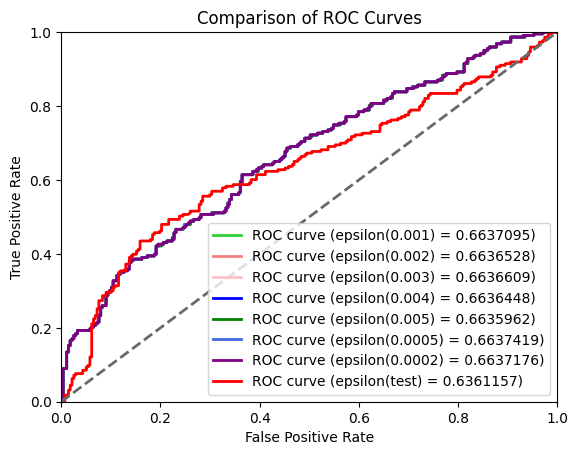

In [ ]:
# perturbation epsilon 별 ROC Curve 비교

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, roc_auc_score
import numpy as np

# 첫번째 데이터셋 로드 및 처리 # perturbation epsilon(0.001)
ep1_original = pd.read_excel("OOD_Detection_15_transformation_rules-main/OOD_Detection-main/ood/perturbation/epsilon/epsilon(0.001).xlsx")
ep1_data = ep1_original.copy()
ep1_data = ep1_data.sort_values(by=['values'], ascending=False)
ep1_data['OOD_roc_label'] = ep1_data.apply(lambda row: 0 if row['OOD 여부'] == 'O' else 1, axis=1)
ep1_label = ep1_data['OOD_roc_label'].tolist()
ep1_score = ep1_data['values'].tolist()

# 두번째 데이터셋 로드 및 처리 # perturbation epsilon(0.002)
ep2_original = pd.read_excel("OOD_Detection_15_transformation_rules-main/OOD_Detection-main/ood/perturbation/epsilon/epsilon(0.002).xlsx")
ep2_data = ep2_original.copy()
ep2_data = ep2_data.sort_values(by=['values'], ascending=False)
ep2_data['OOD_roc_label'] = ep2_data.apply(lambda row: 0 if row['OOD 여부'] == 'O' else 1, axis=1)
ep2_label = ep2_data['OOD_roc_label'].tolist()
ep2_score = ep2_data['values'].tolist()

# 세번째 데이터셋 로드 및 처리 # perturbation epsilon(0.003)
ep3_original = pd.read_excel("OOD_Detection_15_transformation_rules-main/OOD_Detection-main/ood/perturbation/epsilon/epsilon(0.003).xlsx")
ep3_data = ep3_original.copy()
ep3_data = ep3_data.sort_values(by=['values'], ascending=False)
ep3_data['OOD_roc_label'] = ep3_data.apply(lambda row: 0 if row['OOD 여부'] == 'O' else 1, axis=1)
ep3_label = ep3_data['OOD_roc_label'].tolist()
ep3_score = ep3_data['values'].tolist()

# 네번째 데이터셋 로드 및 처리 # perturbation epsilon(0.004)
ep4_original = pd.read_excel("OOD_Detection_15_transformation_rules-main/OOD_Detection-main/ood/perturbation/epsilon/epsilon(0.004).xlsx")
ep4_data = ep4_original.copy()
ep4_data = ep4_data.sort_values(by=['values'], ascending=False)
ep4_data['OOD_roc_label'] = ep4_data.apply(lambda row: 0 if row['OOD 여부'] == 'O' else 1, axis=1)
ep4_label = ep4_data['OOD_roc_label'].tolist()
ep4_score = ep4_data['values'].tolist()

# 다섯번째 데이터셋 로드 및 처리 # perturbation epsilon(0.005)
ep5_original = pd.read_excel("OOD_Detection_15_transformation_rules-main/OOD_Detection-main/ood/perturbation/epsilon/epsilon(0.005).xlsx")
ep5_data = ep5_original.copy()
ep5_data = ep5_data.sort_values(by=['values'], ascending=False)
ep5_data['OOD_roc_label'] = ep5_data.apply(lambda row: 0 if row['OOD 여부'] == 'O' else 1, axis=1)
ep5_label = ep5_data['OOD_roc_label'].tolist()
ep5_score = ep5_data['values'].tolist()

# 여섯번째 데이터셋 로드 및 처리 # perturbation epsilon(0.0005)
ep05_original = pd.read_excel("OOD_Detection_15_transformation_rules-main/OOD_Detection-main/ood/perturbation/epsilon/epsilon(0.0005).xlsx")
ep05_data = ep05_original.copy()
ep05_data = ep05_data.sort_values(by=['values'], ascending=False)
ep05_data['OOD_roc_label'] = ep05_data.apply(lambda row: 0 if row['OOD 여부'] == 'O' else 1, axis=1)
ep05_label = ep05_data['OOD_roc_label'].tolist()
ep05_score = ep05_data['values'].tolist()

# 일곱번째 데이터셋 로드 및 처리 # perturbation epsilon(0.0002)
ep02_original = pd.read_excel("OOD_Detection_15_transformation_rules-main/OOD_Detection-main/ood/perturbation/epsilon/epsilon(0.0002).xlsx")
ep02_data = ep02_original.copy()
ep02_data = ep02_data.sort_values(by=['values'], ascending=False)
ep02_data['OOD_roc_label'] = ep02_data.apply(lambda row: 0 if row['OOD 여부'] == 'O' else 1, axis=1)
ep02_label = ep02_data['OOD_roc_label'].tolist()
ep02_score = ep02_data['values'].tolist()

# test번째 데이터셋 로드 및 처리 # perturbation epsilon(0.0002)
test_original = pd.read_excel("OOD_Detection_15_transformation_rules-main/OOD_Detection-main/ood/perturbation/epsilon/epsilon(10).xlsx")
test_data = test_original.copy()
test_data = test_data.sort_values(by=['values'], ascending=False)
test_data['OOD_roc_label'] = test_data.apply(lambda row: 0 if row['OOD 여부'] == 'O' else 1, axis=1)
test_label = test_data['OOD_roc_label'].tolist()
test_score = test_data['values'].tolist()

# ROC Curve 계산
ep1_fpr, ep1_tpr, _ = roc_curve(ep1_label, ep1_score) # epsilon(0.001)
ep2_fpr, ep2_tpr, _ = roc_curve(ep2_label, ep2_score) # epsilon(0.002)
ep3_fpr, ep3_tpr, _ = roc_curve(ep3_label, ep3_score) # epsilon(0.003)
ep4_fpr, ep4_tpr, _ = roc_curve(ep4_label, ep4_score) # epsilon(0.004)
ep5_fpr, ep5_tpr, _ = roc_curve(ep5_label, ep5_score) # epsilon(0.005)
ep05_fpr, ep05_tpr, _ = roc_curve(ep05_label, ep05_score) # epsilon(0.0005)
ep02_fpr, ep02_tpr, _ = roc_curve(ep02_label, ep02_score) # epsilon(0.0002)
test_fpr, test_tpr, _ = roc_curve(test_label, test_score) # epsilon(0.1)

ep1_roc_auc = auc(ep1_fpr, ep1_tpr) # epsilon(0.001)
ep2_roc_auc = auc(ep2_fpr, ep2_tpr) # epsilon(0.002)
ep3_roc_auc = auc(ep3_fpr, ep3_tpr) # epsilon(0.003)
ep4_roc_auc = auc(ep4_fpr, ep4_tpr) # epsilon(0.004)
ep5_roc_auc = auc(ep5_fpr, ep5_tpr) # epsilon(0.005)
ep05_roc_auc = auc(ep05_fpr, ep05_tpr) # epsilon(0.0005)
ep02_roc_auc = auc(ep02_fpr, ep02_tpr) # epsilon(0.0002)
test_roc_auc = auc(test_fpr, test_tpr) # epsilon(0.0002)



# ROC Curve 그리기
plt.figure()
plt.plot(ep1_fpr, ep1_tpr, color='limegreen', lw=2, label='ROC curve (epsilon(0.001) = %0.7f)' % ep1_roc_auc)
plt.plot(ep2_fpr, ep2_tpr, color='lightcoral', lw=2, label='ROC curve (epsilon(0.002) = %0.7f)' % ep2_roc_auc)
plt.plot(ep3_fpr, ep3_tpr, color='pink', lw=2, label='ROC curve (epsilon(0.003) = %0.7f)' % ep3_roc_auc)
plt.plot(ep4_fpr, ep4_tpr, color='blue', lw=2, label='ROC curve (epsilon(0.004) = %0.7f)' % ep4_roc_auc)
plt.plot(ep5_fpr, ep5_tpr, color='green', lw=2, label='ROC curve (epsilon(0.005) = %0.7f)' % ep5_roc_auc)
plt.plot(ep05_fpr, ep05_tpr, color='royalblue', lw=2, label='ROC curve (epsilon(0.0005) = %0.7f)' % ep05_roc_auc)
plt.plot(ep02_fpr, ep02_tpr, color='purple', lw=2, label='ROC curve (epsilon(0.0002) = %0.7f)' % ep02_roc_auc)

plt.plot(test_fpr, test_tpr, color='red', lw=2, label='ROC curve (epsilon(test) = %0.7f)' % test_roc_auc)
# plt.plot(do_fpr, do_tpr, color='limegreen', lw=2, label='DROPOUT(0.1)')
# plt.plot(do02_fpr, do02_tpr, color='lightcoral', lw=2, label='DROPOUT(0.2)')
# plt.plot(do03_fpr, do03_tpr, color='red', lw=2, label='DROPOUT(0.3)')
# plt.plot(do04_fpr, do04_tpr, color='blue', lw=2, label='DROPOUT(0.4)')
# plt.plot(do05_fpr, do05_tpr, color='green', lw=2, label='DROPOUT(0.5)')
# plt.plot(do005_fpr, do005_tpr, color='royalblue', lw=2, label='DROPOUT(0.05)')
plt.plot([0, 1], [0, 1], color='dimgrey', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Comparison of ROC Curves')
plt.legend(loc="lower right")
plt.show()


In [ ]:
# # outputs2의 FPR95 찾기
# # max_values_outputs2_np는 모델의 예측 확률값을 담고 있는 numpy 배열

# # 확률값을 내림차순으로 정렬합니다.
# sorted_probabilities = np.sort(values_output1_np)[::-1]

# # 상위 95%에 해당하는 인덱스 찾기
# index_at_95_tpr = int(len(sorted_probabilities) * 0.95) - 1

# # 해당 인덱스에서의 threshold 값
# threshold_at_95_tpr = sorted_probabilities[index_at_95_tpr]

# print("TPR 95%에서의 threshold 값:", threshold_at_95_tpr)

sorted_probabilities = np.sort(values_output2_np)

# 하위 5%에 해당하는 인덱스 찾기
index_at_5_fpr = int(len(sorted_probabilities) * 0.05) - 1

# 해당 인덱스에서의 threshold 값
threshold_at_5_fpr = sorted_probabilities[index_at_5_fpr]

print("FPR 95%에서의 threshold 값:", threshold_at_5_fpr)

In [ ]:
# perturbation(word embedding x) 적용코드 1

%load_ext autoreload
%autoreload 2
CUDA_VISIBLE_DEVICES=1

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
import argparse
import torch

#from tqdm.notebook import tqdm, trange
from tqdm import tqdm, trange

from models.classificaion_15_transformation import (
    classificaion_15_transformation_rules, # 미분(CLS 벡터)
    classificaion_15_transformation_rules_dropout, # 드랍아웃 레이어
    classificaion_15_transformation_rules_ip, # 미분(word embedding)
    MyDataset,
    my_collate_fn,
    my_collate_fn_rationale,
    load_sst
)

if __name__ == "__main__":
    parser = argparse.ArgumentParser()
    parser.add_argument("--gpu", type=str, default="1")
    parser.add_argument("--seed", type=int, default=0)
    parser.add_argument(
        "--val_filename",
        type=str,
        default="datasets/15_transformation_rules/goldset/500_goldset.txt"
        
    )
    parser.add_argument(
        "--val_rationale",
        type=str,
        default="datasets/eSNLI/esnli_test.rationale_idx"
    )
    
    parser.add_argument(
        "--token_cls", 
        action='store_true'
    )
    
    parser.add_argument(
        "--model_path",
        type=str,
        default="outputs/classification_15_transformation_rules/epoch=11-val_acc=0.9656-val_f1=0.9414.ckpt"
    )
    
    parser.add_argument(
        "--dataset",
        type=str,
        default="coco", # coco, esnli
    )

    hparams, _ = parser.parse_known_args()
    
    #torch.manual_seed(hparams.seed) # 랜덤 시드 고정
    
    os.environ["CUDA_VISIBLE_DEVICES"] = hparams.gpu

device = "cuda:0"

model = classificaion_15_transformation_rules.load_from_checkpoint(hparams.model_path).to(device) # 내가 원하는 형태로 output만 뽑기
model.hparams.model_path = hparams.model_path

model.freeze()
model.prepare_data()

In [ ]:
# perturbation(word embedding x) 적용 코드 2
import numpy as np
import torch.nn.functional as F

def softmax_with_temperature(logits, T):
    logits = logits / T  # Temperature scaling
    max_logits = torch.max(logits, dim=1, keepdim=True)[0]
    exp_logits = torch.exp(logits - max_logits)
    sum_exp_logits = torch.sum(exp_logits, dim=1, keepdim=True)
    y = exp_logits / sum_exp_logits
    return y

val_dataset, _ = load_sst(
                hparams.val_filename, None, hparams.dataset, model.hparams.num_labels, hparams.val_rationale, model.hparams.token_cls
            )
val_dataloader = torch.utils.data.DataLoader(
            val_dataset, batch_size=model.hparams.batch_size, collate_fn=my_collate_fn_rationale, num_workers=8
        )

## label=15
val_acc, num = [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0], [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]
num_p = [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0] # precision

# for j  in range(1, 101): # dropout n=100
all_tensor_outputs1_values = []
all_tensor_outputs1_indices = []

all_tensor_outputs2_values = []
all_tensor_outputs2_indices = []

# softmax with temperature scaling 적용
T = 700 # T = 1000 / 500 적용해보기
epsilon = 0.5 # 0.001 0.002 0.003 0.004 0.005로 나눠서 해보기

# 입력데이터를 모델에 전달
for i, batch in tqdm(enumerate(model.val_dataloader()), total=len(model.val_dataset) // model.hparams.batch_size): # Coco
    inputs = model.tokenizer.batch_encode_plus(batch[0], pad_to_max_length=True, return_tensors='pt').to(device)
    input_ids = inputs['input_ids']
    mask = inputs['attention_mask']
    token_type_ids = inputs['token_type_ids']
    labels = batch[1].to(device)
    
    # model.train()
    outputs1, outputs2 = model.forward(input_ids, mask, token_type_ids, temperature=T, epsilon=epsilon)
    model.eval()
    
    
    # outputs1과 outputs2에 대해 소프트맥스 함수를 적용
    softmaxed_outputs1 = F.softmax(outputs1, dim=1) 
    softmaxed_outputs2 = F.softmax(outputs2, dim=1) # 이 코드로 진행
    
    # softmaxed_outputs1과 softmaxed_outputs2에 대한 최대 값(msp_score, 예측 index)
    # max_values_outputs1, max_indices_outputs1 = torch.max(softmaxed_outputs1, dim=1)
    max_values_outputs2, max_indices_outputs2 = torch.max(softmaxed_outputs2, dim=1)
    max_values_outputs1, max_indices_outputs1 = torch.max(softmaxed_outputs1, dim=1)
    # max_values_outputs2, max_indices_outputs2 = torch.max(outputs2, dim=1)
    
    # 최대값과 인덱스 리스트에 추가
    all_tensor_outputs1_indices.append(max_indices_outputs1) # outputs1 인덱스 값 추가
    all_tensor_outputs1_values.append(max_values_outputs1) # outputs1 최대 값 추가

    all_tensor_outputs2_indices.append(max_indices_outputs2) # outputs2 인덱스 값 추가
    all_tensor_outputs2_values.append(max_values_outputs2) # outputs2 최대 값 추가
    
    # 각 배치별 결과값 하나로(500개)
    values_output1 = torch.cat(all_tensor_outputs1_values, 0)
    values_output1_np = values_output1.detach().cpu().numpy() # outputs1 최대값 하나로
    indices_output1 = torch.cat(all_tensor_outputs1_indices, 0)
    indices_output1_np = indices_output1.detach().cpu().numpy() # outputs1 인덱스 하나로
    values_output2 = torch.cat(all_tensor_outputs2_values, 0)
    values_output2_np = values_output2.detach().cpu().numpy() # outputs2 최대값 하나로
    indices_output2 = torch.cat(all_tensor_outputs2_indices, 0)
    indices_output2_np = indices_output2.detach().cpu().numpy() # outputs2 인덱스 하나로

# 500개의 인덱스 및 score 출력
# print(values_output1_np) 
# print(indices_output1_np)

# print(values_output2_np)
print(values_output2_np)


# # # 엑셀로 파일저장
output_file = "OOD_Detection_15_transformation_rules-main/OOD_Detection-main/ood/dataset_split/perturbation/per_score_e5.txt" # 파일저장
with open(output_file, "w") as file:
    for item in values_output2_np:
        file.write(str(item) + "\n")


8it [00:01,  5.54it/s]                       

[0.07148939 0.07148679 0.07146297 0.07148424 0.07147574 0.07148964
 0.07145682 0.07145503 0.07145675 0.07149065 0.07144427 0.07148708
 0.07146089 0.07145616 0.07148603 0.07145051 0.07145794 0.07146926
 0.07149225 0.07149314 0.07148565 0.07148603 0.07148053 0.07148804
 0.0714807  0.07148726 0.07146212 0.07145723 0.07146993 0.0714866
 0.07146609 0.07149067 0.07146493 0.07148919 0.07145394 0.07148214
 0.07148296 0.07147783 0.0714683  0.07147692 0.07148584 0.07146513
 0.07148708 0.07147028 0.07149182 0.07147977 0.0714886  0.07146362
 0.07149058 0.07148522 0.07149308 0.0714775  0.07147367 0.07148538
 0.07149018 0.07147936 0.07148764 0.07148702 0.07149166 0.0714543
 0.07148704 0.07146735 0.0714815  0.07144263 0.07144611 0.07145546
 0.07149152 0.07148355 0.07148442 0.07147546 0.07149033 0.07146899
 0.07146374 0.07148301 0.07146236 0.0714758  0.07148103 0.07149267
 0.07149117 0.07147576 0.07148509 0.07148871 0.0714843  0.07146281
 0.0714894  0.07146771 0.07146515 0.07147519 0.07146337 0.071492

In [ ]:
# perturbation(word embedding x) 한 결과 dataframe으로 만들기
import pandas as pd
per_e2_score = "OOD_Detection_15_transformation_rules-main/OOD_Detection-main/ood/dataset_split/perturbation/per_score_e2.txt"
per_e3_score = "OOD_Detection_15_transformation_rules-main/OOD_Detection-main/ood/dataset_split/perturbation/per_score_e3.txt"
per_e4_score = "OOD_Detection_15_transformation_rules-main/OOD_Detection-main/ood/dataset_split/perturbation/per_score_e4.txt"
per_e5_score = "OOD_Detection_15_transformation_rules-main/OOD_Detection-main/ood/dataset_split/perturbation/per_score_e5.txt"
# per_e034_score = "OOD_Detection_15_transformation_rules-main/OOD_Detection-main/ood/dataset_split/perturbation/per_score_e034.txt"
# per_e035_score = "OOD_Detection_15_transformation_rules-main/OOD_Detection-main/ood/dataset_split/perturbation/per_score_e035.txt"
# per_e036_score = "OOD_Detection_15_transformation_rules-main/OOD_Detection-main/ood/dataset_split/perturbation/per_score_e036.txt"
# per_e037_score = "OOD_Detection_15_transformation_rules-main/OOD_Detection-main/ood/dataset_split/perturbation/per_score_e037.txt"
# per_e038_score = "OOD_Detection_15_transformation_rules-main/OOD_Detection-main/ood/dataset_split/perturbation/per_score_e038.txt"
# per_e039_score = "OOD_Detection_15_transformation_rules-main/OOD_Detection-main/ood/dataset_split/perturbation/per_score_e039.txt"
# per_e08_score = "OOD_Detection_15_transformation_rules-main/OOD_Detection-main/ood/dataset_split/perturbation/per_score_e08.txt"
# per_e09_score = "OOD_Detection_15_transformation_rules-main/OOD_Detection-main/ood/dataset_split/perturbation/per_score_e09.txt"


# 파일 읽어서 리스트로 변환
with open(per_e2_score, 'r') as file:
    per_e2_score = file.read().splitlines()
with open(per_e3_score, 'r') as file:
    per_e3_score = file.read().splitlines()
with open(per_e4_score, 'r') as file:
    per_e4_score = file.read().splitlines()
with open(per_e5_score, 'r') as file:
    per_e5_score = file.read().splitlines()
# with open(per_e034_score, 'r') as file:
#     per_e034_score = file.read().splitlines()
# with open(per_e035_score, 'r') as file:
#     per_e035_score = file.read().splitlines()
# with open(per_e036_score, 'r') as file:
#     per_e036_score = file.read().splitlines()
# with open(per_e037_score, 'r') as file:
#     per_e037_score = file.read().splitlines()
# with open(per_e038_score, 'r') as file:
#     per_e038_score = file.read().splitlines()  
# with open(per_e039_score, 'r') as file:
#     per_e039_score = file.read().splitlines()  
# with open(per_e08_score, 'r') as file:
#     per_e08_score = file.read().splitlines()  
# with open(per_e09_score, 'r') as file:
#     per_e09_score = file.read().splitlines()                                  
    
df = pd.DataFrame({
'Column1': per_e2_score,
'Column2': per_e3_score,
'Column3': per_e4_score,
'Column4': per_e5_score,
# 'Column6': per_e034_score,
# 'Column7': per_e035_score,
# 'Column8': per_e036_score,
# 'Column9': per_e037_score,
# 'Column10': per_e038_score,
# 'Column11': per_e039_score,
# 'Column12': per_e08_score,
# 'Column13': per_e09_score,
})

df.columns = ['e2', 'e3', 'e4', 'e5']

output_file_path = 'OOD_Detection_15_transformation_rules-main/OOD_Detection-main/ood/dataset_split/per_score_e_all.xlsx'

# 데이터프레임을 엑셀 파일로 저장합니다.
df.to_excel(output_file_path, index=False)

# df['values'] = pd.to_numeric(df['values'])

# # 'OOD' 열을 추가하고 조건에 따라 'O' 또는 'X' 할당
# df['OOD_TEST'] = df['values'].apply(lambda x: 'O' if x > 0.07144298 else 'X')

# df

# output_file_path = 'OOD_Detection_15_transformation_rules-main/OOD_Detection-main/ood/ood/perturbation/perturbation_output_test.xlsx'
# df.to_excel(output_file_path, index=False)

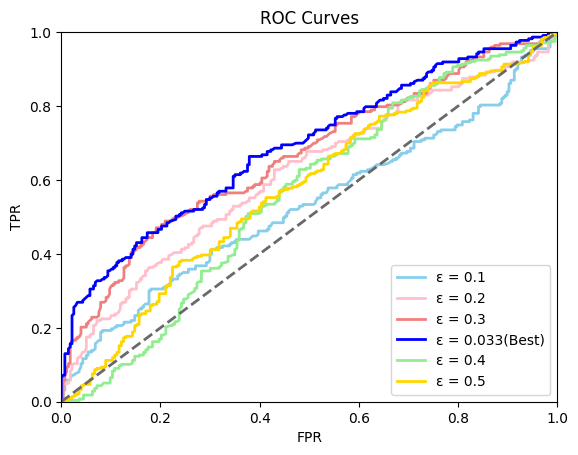

In [ ]:
# perturbation(word embedding x) epsilon 별 ROC Curve 비교

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, roc_auc_score
import numpy as np

# 첫번째 데이터셋 로드 및 처리 # perturbation epsilon(0.1)
ep1_original = pd.read_excel("OOD_Detection_15_transformation_rules-main/OOD_Detection-main/ood/dataset_split/goldset_new.xlsx")
ep1_data = ep1_original.copy()
# ep1_data = ep1_data.sort_values(by=['values'], ascending=False)
ep1_data['OOD_roc_label'] = ep1_data.apply(lambda row: 0 if row['OOD여부'] == 'O' else 1, axis=1)
ep1_label = ep1_data['OOD_roc_label'].tolist()
ep1_score = ep1_data['e033'].tolist()

# 두번째 데이터셋 로드 및 처리 # perturbation epsilon(0.01)
ep2_original = pd.read_excel("OOD_Detection_15_transformation_rules-main/OOD_Detection-main/ood/dataset_split/goldset_new.xlsx")
ep2_data = ep2_original.copy()
# ep2_data = ep2_data.sort_values(by=['values'], ascending=False)
ep2_data['OOD_roc_label'] = ep2_data.apply(lambda row: 0 if row['OOD여부'] == 'O' else 1, axis=1)
ep2_label = ep2_data['OOD_roc_label'].tolist()
ep2_score = ep2_data['e1'].tolist()

# 세번째 데이터셋 로드 및 처리 # perturbation epsilon(0.001)
ep3_original = pd.read_excel("OOD_Detection_15_transformation_rules-main/OOD_Detection-main/ood/dataset_split/goldset_new.xlsx")
ep3_data = ep3_original.copy()
# ep3_data = ep3_data.sort_values(by=['values'], ascending=False)
ep3_data['OOD_roc_label'] = ep3_data.apply(lambda row: 0 if row['OOD여부'] == 'O' else 1, axis=1)
ep3_label = ep3_data['OOD_roc_label'].tolist()
ep3_score = ep3_data['e2'].tolist()

# 네번째 데이터셋 로드 및 처리 # perturbation epsilon(0.02)
ep4_original = pd.read_excel("OOD_Detection_15_transformation_rules-main/OOD_Detection-main/ood/dataset_split/goldset_new.xlsx")
ep4_data = ep4_original.copy()
# ep4_data = ep4_data.sort_values(by=['per_score'], ascending=False)
ep4_data['OOD_roc_label'] = ep4_data.apply(lambda row: 0 if row['OOD여부'] == 'O' else 1, axis=1)
ep4_label = ep4_data['OOD_roc_label'].tolist()
ep4_score = ep4_data['e3'].tolist()

# 다섯번째 데이터셋 로드 및 처리 # perturbation epsilon(0.03)
ep5_original = pd.read_excel("OOD_Detection_15_transformation_rules-main/OOD_Detection-main/ood/dataset_split/goldset_new.xlsx")
ep5_data = ep5_original.copy()
# ep5_data = ep5_data.sort_values(by=['values'], ascending=False)
ep5_data['OOD_roc_label'] = ep5_data.apply(lambda row: 0 if row['OOD여부'] == 'X' else 1, axis=1)
ep5_label = ep5_data['OOD_roc_label'].tolist()
ep5_score = ep5_data['e4'].tolist()


# test번째 데이터셋 로드 및 처리 # perturbation epsilon(0.04)
test_original = pd.read_excel("OOD_Detection_15_transformation_rules-main/OOD_Detection-main/ood/dataset_split/goldset_new.xlsx")
test_data = test_original.copy()
# test_data = test_data.sort_values(by=['values'], ascending=False)
test_data['OOD_roc_label'] = test_data.apply(lambda row: 0 if row['OOD여부'] == 'X' else 1, axis=1)
test_label = test_data['OOD_roc_label'].tolist()
test_score = test_data['e5'].tolist()

# test번째 데이터셋 로드 및 처리 # perturbation epsilon(0.05)
test2_original = pd.read_excel("OOD_Detection_15_transformation_rules-main/OOD_Detection-main/ood/dataset_split/goldset_new.xlsx")
test2_data = test2_original.copy()
# test2_data = test2_data.sort_values(by=['values'], ascending=False)
test2_data['OOD_roc_label'] = test2_data.apply(lambda row: 0 if row['OOD여부'] == 'O' else 1, axis=1)
test2_label = test2_data['OOD_roc_label'].tolist()
test2_score = test2_data['e037'].tolist()

# ROC Curve 계산
ep1_fpr, ep1_tpr, _ = roc_curve(ep1_label, ep1_score) # 0.01
ep2_fpr, ep2_tpr, _ = roc_curve(ep2_label, ep2_score) # 0.013
ep3_fpr, ep3_tpr, _ = roc_curve(ep3_label, ep3_score) # 0.015
ep4_fpr, ep4_tpr, _ = roc_curve(ep4_label, ep4_score) # 0.016
ep5_fpr, ep5_tpr, _ = roc_curve(ep5_label, ep5_score) # 0.017
test_fpr, test_tpr, _ = roc_curve(test_label, test_score) # 0.02
test2_fpr, test2_tpr, _ = roc_curve(test2_label, test2_score) # 0.03

ep1_roc_auc = auc(ep1_fpr, ep1_tpr) # 0.01
ep2_roc_auc = auc(ep2_fpr, ep2_tpr) # 0.013
ep3_roc_auc = auc(ep3_fpr, ep3_tpr) # 0.015
ep4_roc_auc = auc(ep4_fpr, ep4_tpr) # 0.016
ep5_roc_auc = auc(ep5_fpr, ep5_tpr) # 0.017
test_roc_auc = auc(test_fpr, test_tpr) #0.02
test2_roc_auc = auc(test2_fpr, test2_tpr) #0.03



# ROC Curve 그리기
plt.figure()
# plt.plot(ep1_fpr, ep1_tpr, color='limegreen', lw=2, label='epsilon(0.031)' % ep1_roc_auc)
# plt.plot(ep2_fpr, ep2_tpr, color='lightcoral', lw=2, label='epsilon(0.032)' % ep2_roc_auc)
# plt.plot(ep3_fpr, ep3_tpr, color='pink', lw=2, label='epsilon(0.033)' % ep3_roc_auc)
# plt.plot(ep4_fpr, ep4_tpr, color='blue', lw=2, label='epsilon(0.034)' % ep4_roc_auc)
# plt.plot(ep5_fpr, ep5_tpr, color='green', lw=2, label='epsilon(0.035)' % ep5_roc_auc)
# plt.plot(test_fpr, test_tpr, color='red', lw=2, label='epsilon(0.036)' % test_roc_auc)
# plt.plot(test_fpr, test_tpr, color='skyblue', lw=2, label='epsilon(0.037)' % test2_roc_auc)

plt.plot(ep4_fpr, ep4_tpr, color='skyblue', lw=2, label='ε = 0.1' % ep4_roc_auc)
plt.plot(ep3_fpr, ep3_tpr, color='pink', lw=2, label='ε = 0.2' % ep3_roc_auc)
plt.plot(ep2_fpr, ep2_tpr, color='lightcoral', lw=2, label='ε = 0.3' % ep2_roc_auc)
plt.plot(ep1_fpr, ep1_tpr, color='blue', lw=2, label='ε = 0.033(Best)' % ep1_roc_auc)
plt.plot(ep5_fpr, ep5_tpr, color='lightgreen', lw=2, label='ε = 0.4' % ep5_roc_auc)
plt.plot(test_fpr, test_tpr, color='gold', lw=2, label='ε = 0.5' % test_roc_auc)
# plt.plot(test_fpr, test_tpr, color='purple', lw=2, label='epsilon(0.05) = %0.5f)' % test2_roc_auc)

# plt.plot(ep2_fpr, ep2_tpr, color='lightcoral', lw=2, label='(epsilon(0.1) = %0.5f)' % ep2_roc_auc)
# plt.plot(ep3_fpr, ep3_tpr, color='pink', lw=2, label='epsilon(0.2)ε = %0.5f)' % ep3_roc_auc)
# plt.plot(ep4_fpr, ep4_tpr, color='blue', lw=2, label='epsilon(0.3) = %0.5f)' % ep4_roc_auc)
# plt.plot(ep5_fpr, ep5_tpr, color='green', lw=2, label='epsilon(0.4) = %0.5f)' % ep5_roc_auc)
# plt.plot(test_fpr, test_tpr, color='red', lw=2, label='epsilon(0.5) = %0.5f)' % test_roc_auc)
# plt.plot(test_fpr, test_tpr, color='purple', lw=2, label='epsilon(0.05) = %0.5f)' % test2_roc_auc)
plt.plot([0, 1], [0, 1], color='dimgrey', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC Curves')
plt.legend(loc="lower right")
plt.show()


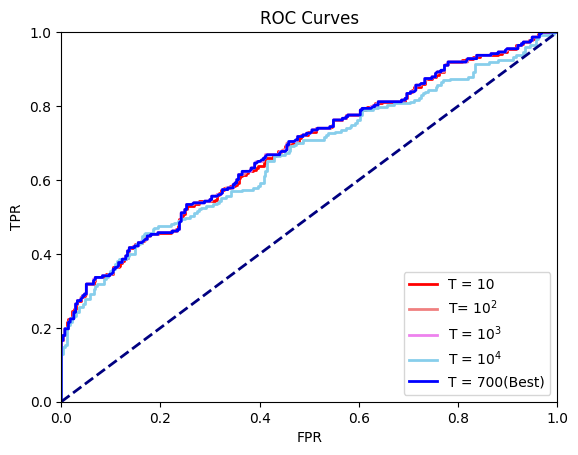

In [ ]:
# T에 따른 그래프 그려보기(10, 100, 10000, 100000)

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, roc_auc_score
import numpy as np

# 첫 번째 데이터셋 로드 및 처리 1000 (e 0.016기준)
goldset_original = pd.read_excel("OOD_Detection_15_transformation_rules-main/OOD_Detection-main/ood/dataset_split/goldset_new.xlsx")
gs_roc_curve_data = goldset_original.copy()
# gs_roc_curve_data = gs_roc_curve_data.sort_values(by=['MSP_score'], ascending=False)
gs_roc_curve_data['OOD_roc_label'] = gs_roc_curve_data.apply(lambda row: 0 if row['OOD여부'] == 'O' else 1, axis=1)
gs_list_from_roc_label = gs_roc_curve_data['OOD_roc_label'].tolist()
gs_list_from_score = gs_roc_curve_data['t10'].tolist()

# 두 번째 데이터셋 로드 및 처리(T=10)
ts_after_sort_original = pd.read_excel("OOD_Detection_15_transformation_rules-main/OOD_Detection-main/ood/dataset_split/goldset_new.xlsx")
ts_roc_curve_data = ts_after_sort_original.copy()
# ts_roc_curve_data = ts_roc_curve_data.sort_values(by=['MSP_score'], ascending=False)
ts_roc_curve_data['OOD_roc_label'] = ts_roc_curve_data.apply(lambda row: 0 if row['OOD여부'] == 'O' else 1, axis=1)
ts_list_from_roc_label = ts_roc_curve_data['OOD_roc_label'].tolist()
ts_list_from_score = ts_roc_curve_data['t100'].tolist()

# T=100
ts10_original = pd.read_excel("OOD_Detection_15_transformation_rules-main/OOD_Detection-main/ood/dataset_split/goldset_new.xlsx")
ts10_roc_curve_data = ts10_original.copy()
# ts10_roc_curve_data = ts10_roc_curve_data.sort_values(by=['MSP_score'], ascending=False)
ts10_roc_curve_data['OOD_roc_label'] = ts10_roc_curve_data.apply(lambda row: 0 if row['OOD여부'] == 'O' else 1, axis=1)
ts10_list_from_roc_label = ts10_roc_curve_data['OOD_roc_label'].tolist()
ts10_list_from_score = ts10_roc_curve_data['t500'].tolist()

# T=200
ts100_original = pd.read_excel("OOD_Detection_15_transformation_rules-main/OOD_Detection-main/ood/dataset_split/goldset_new.xlsx")
ts100_roc_curve_data = ts100_original.copy()
# ts100_roc_curve_data = ts100_roc_curve_data.sort_values(by=['MSP_score'], ascending=False)
ts100_roc_curve_data['OOD_roc_label'] = ts100_roc_curve_data.apply(lambda row: 0 if row['OOD여부'] == 'O' else 1, axis=1)
ts100_list_from_roc_label = ts100_roc_curve_data['OOD_roc_label'].tolist()
ts100_list_from_score = ts100_roc_curve_data['t700'].tolist()

# T=300
ts10000_original = pd.read_excel("OOD_Detection_15_transformation_rules-main/OOD_Detection-main/ood/dataset_split/goldset_new.xlsx")
ts10000_roc_curve_data = ts10000_original.copy()
# ts10000_roc_curve_data = ts10000_roc_curve_data.sort_values(by=['MSP_score'], ascending=False)
ts10000_roc_curve_data['OOD_roc_label'] = ts10000_roc_curve_data.apply(lambda row: 0 if row['OOD여부'] == 'O' else 1, axis=1)
ts10000_list_from_roc_label = ts10000_roc_curve_data['OOD_roc_label'].tolist()
ts10000_list_from_score = ts10000_roc_curve_data['msp_wo_ts_score'].tolist()

# t400
ts100000_original = pd.read_excel("OOD_Detection_15_transformation_rules-main/OOD_Detection-main/ood/dataset_split/goldset_new.xlsx")
ts100000_roc_curve_data = ts100000_original.copy()
# ts100000_roc_curve_data = ts100000_roc_curve_data.sort_values(by=['MSP_score'], ascending=False)
ts100000_roc_curve_data['OOD_roc_label'] = ts100000_roc_curve_data.apply(lambda row: 0 if row['OOD여부'] == 'O' else 1, axis=1)
ts100000_list_from_roc_label = ts100000_roc_curve_data['OOD_roc_label'].tolist()
ts100000_list_from_score = ts100000_roc_curve_data['t900'].tolist()

# ROC Curve 계산
gs_fpr, gs_tpr, _ = roc_curve(gs_list_from_roc_label, gs_list_from_score)
ts_fpr, ts_tpr, _ = roc_curve(ts_list_from_roc_label, ts_list_from_score)
ts10_fpr, ts10_tpr, _ = roc_curve(ts10_list_from_roc_label, ts10_list_from_score)
ts100_fpr, ts100_tpr, _ = roc_curve(ts100_list_from_roc_label, ts100_list_from_score)
ts10000_fpr, ts10000_tpr, _ = roc_curve(ts10000_list_from_roc_label, ts10000_list_from_score)
ts100000_fpr, ts100000_tpr, _ = roc_curve(ts100000_list_from_roc_label, ts100000_list_from_score)

gs_roc_auc = auc(gs_fpr, gs_tpr)
ts_roc_auc = auc(ts_fpr, ts_tpr)
ts10_roc_auc = auc(ts10_fpr, ts10_tpr)
ts100_roc_auc = auc(ts100_fpr, ts100_tpr)
ts10000_roc_auc = auc(ts10000_fpr, ts10000_tpr)
ts100000_roc_auc = auc(ts100000_fpr, ts100000_tpr)


# ROC Curve 그리기
plt.figure()
# plt.plot(gs_fpr, gs_tpr, color='red', lw=2, label='ROC curve (MSP + T10)' % gs_roc_auc)
# plt.plot(ts_fpr, ts_tpr, color='lightcoral', lw=2, label='ROC curve (MSP + T100)' % ts_roc_auc)
# plt.plot(ts10_fpr, ts10_tpr, color='violet', lw=2, label='ROC curve (MSP + T500)' % ts10_roc_auc)
# plt.plot(ts100_fpr, ts100_tpr, color='wheat', lw=2, label='ROC curve (MSP + T700)' % ts100_roc_auc)
# plt.plot(ts10000_fpr, ts10000_tpr, color='skyblue', lw=2, label='ROC curve (MSP w/o TS)' % ts10000_roc_auc)

plt.plot(gs_fpr, gs_tpr, color='red', lw=2, label='T = 10' % gs_roc_auc)
plt.plot(ts_fpr, ts_tpr, color='lightcoral', lw=2, label='T= $10^2$' % ts_roc_auc)
plt.plot(ts10_fpr, ts10_tpr, color='violet', lw=2, label='T = $10^3$' % ts10_roc_auc)
plt.plot(ts10000_fpr, ts10000_tpr, color='skyblue', lw=2, label='T = $10^4$' % ts10000_roc_auc)
plt.plot(ts100_fpr, ts100_tpr, color='blue', lw=2, label='T = 700(Best)' % ts100_roc_auc)

# plt.plot(ts10000_fpr, ts10000_tpr, color='lightgreen', lw=2, label='MSP + T=$10^4$')
# # plt.plot(ts100000_fpr, ts100000_tpr, color='gold', lw=2, label='MSP + T=T=$10^5$')
# plt.plot(gs_fpr, gs_tpr, color='skyblue', lw=2, label='ROC curve (MSP T100 = %0.6f)' % gs_roc_auc)
# plt.plot(ts_fpr, ts_tpr, color='lightcoral', lw=2, label='ROC curve (MSP + T500 = %0.6f)' % ts_roc_auc)
# plt.plot(ts10_fpr, ts10_tpr, color='violet', lw=2, label='ROC curve (MSP + T600 = %0.6f)' % ts10_roc_auc)
# plt.plot(ts100_fpr, ts100_tpr, color='wheat', lw=2, label='ROC curve (MSP + T700 = %0.6f)' % ts100_roc_auc)
# plt.plot(ts10000_fpr, ts10000_tpr, color='skyblue', lw=2, label='ROC curve (MSP + T800 = %0.6f)' % ts10000_roc_auc)
# plt.plot(ts100000_fpr, ts100000_tpr, color='gold', lw=2, label='ROC curve (MSP + TS100000= %0.5f)' % ts100000_roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC Curves')
plt.legend(loc="lower right")
plt.show()


In [ ]:
# perturbation 한 결과 dataframe으로 만들기
import pandas as pd
# outputs2_indices_path = "OOD_Detection_15_transformation_rules-main/OOD_Detection-main/ood/ood/perturbation/outputs2_indices.txt"
# outputs2_values_path = "OOD_Detection_15_transformation_rules-main/OOD_Detection-main/ood/ood/perturbation/outputs2_values.txt"
outputs1_indices_path = "OOD_Detection_15_transformation_rules-main/OOD_Detection-main/ood/ood/perturbation/outputs2_indices_new.txt"
outputs1_values_path = "OOD_Detection_15_transformation_rules-main/OOD_Detection-main/ood//ood/perturbation/epsilon2/epsilon(0.005).txt"

# 파일 읽어서 리스트로 변환
with open(outputs1_indices_path, 'r') as file:
    indices = file.read().splitlines()

with open(outputs1_values_path, 'r') as file:
    values = file.read().splitlines()
    
df = pd.DataFrame({
'Column1': indices,
'Column2': values
})

df.columns = ['indices', 'values']

output_file_path = 'OOD_Detection_15_transformation_rules-main/OOD_Detection-main/ood//ood/perturbation/epsilon2/epsilon(0.005).xlsx'

# 데이터프레임을 엑셀 파일로 저장합니다.
df.to_excel(output_file_path, index=False)

# df['values'] = pd.to_numeric(df['values'])

# # 'OOD' 열을 추가하고 조건에 따라 'O' 또는 'X' 할당
# df['OOD_TEST'] = df['values'].apply(lambda x: 'O' if x > 0.07144298 else 'X')

# df

# output_file_path = 'OOD_Detection_15_transformation_rules-main/OOD_Detection-main/ood/ood/perturbation/perturbation_output_test.xlsx'
# df.to_excel(output_file_path, index=False)

In [ ]:
import pandas as pd
file_path = 'OOD_Detection_15_transformation_rules-main/OOD_Detection-main/ood/ood/perturbation/perturbation_output2_t100.xlsx'

per_df = pd.read_excel(file_path)

# df[['FirstIndex', 'SecondIndex']] = df['인덱스'].str.extract(r'\[(\d+)\]\[(\d+)\]')
# df['FirstIndex'] = pd.to_numeric(df['FirstIndex'])
# df['SecondIndex'] = pd.to_numeric(df['SecondIndex'])
# df_sorted = df.sort_values(by=['FirstIndex', 'SecondIndex'])

per_df

# output_file_path = 'OOD_Detection_15_transformation_rules-main/OOD_Detection-main/ood/ood/perturbation/GOLDSET_인덱스로정렬.xlsx'
# df_sorted.to_excel(output_file_path, index=False)

In [ ]:
# goldset 인덱스로 정렬
import pandas as pd
file_path = 'OOD_Detection_15_transformation_rules-main/OOD_Detection-main/ood/ood/GOLDSET(dropout 신뢰도추가).xlsx'

df = pd.read_excel(file_path)

df[['FirstIndex', 'SecondIndex']] = df['인덱스'].str.extract(r'\[(\d+)\]\[(\d+)\]')
df['FirstIndex'] = pd.to_numeric(df['FirstIndex'])
df['SecondIndex'] = pd.to_numeric(df['SecondIndex'])
df_sorted = df.sort_values(by=['FirstIndex', 'SecondIndex'])

df_sorted

# output_file_path = 'OOD_Detection_15_transformation_rules-main/OOD_Detection-main/ood/ood/perturbation/GOLDSET_인덱스로정렬.xlsx'
# df_sorted.to_excel(output_file_path, index=False)

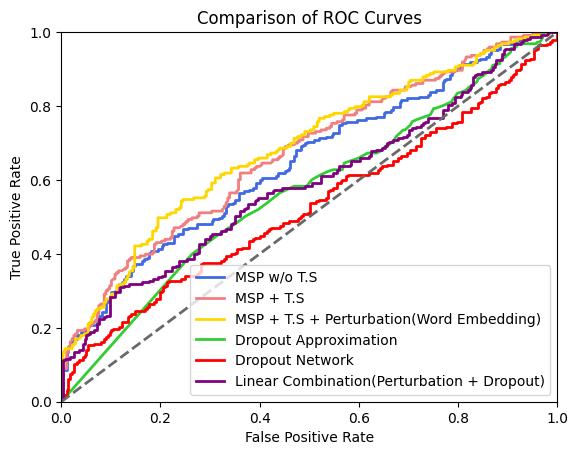

In [ ]:
# 3개의 ROC Curve 하나로 합치기

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, roc_auc_score
import numpy as np

# 첫 번째 데이터셋 로드 및 처리 # GOLDSET(MSP)
goldset_original = pd.read_excel("OOD_Detection_15_transformation_rules-main/OOD_Detection-main/ood/GOLDSET.xlsx")
gs_roc_curve_data = goldset_original.copy()
gs_roc_curve_data = gs_roc_curve_data.sort_values(by=['MSP_score'], ascending=False)
gs_roc_curve_data['OOD_roc_label'] = gs_roc_curve_data.apply(lambda row: 0 if row['OOD 여부'] == 'O' else 1, axis=1)
gs_list_from_roc_label = gs_roc_curve_data['OOD_roc_label'].tolist()
gs_list_from_score = gs_roc_curve_data['MSP_score'].tolist()

# 두 번째 데이터셋 로드 및 처리 # MSP + TS(T=1000)
ts_after_sort_original = pd.read_excel("OOD_Detection_15_transformation_rules-main/OOD_Detection-main/ood/GOLDSET기준_TS적용후.xlsx")
ts_roc_curve_data = ts_after_sort_original.copy()
ts_roc_curve_data = ts_roc_curve_data.sort_values(by=['MSP_score'], ascending=False)
ts_roc_curve_data['OOD_roc_label'] = ts_roc_curve_data.apply(lambda row: 0 if row['OOD 여부'] == 'O' else 1, axis=1)
ts_list_from_roc_label = ts_roc_curve_data['OOD_roc_label'].tolist()
ts_list_from_score = ts_roc_curve_data['MSP_score'].tolist()

# 세 번째 데이터셋 로드 및 처리 # Dropout Bayesian Approximation
dropout_original = pd.read_excel("OOD_Detection_15_transformation_rules-main/OOD_Detection-main/ood/dropout(0.1)_total100_notsort.xlsx")
dropout_data = dropout_original.copy()
dropout_data = dropout_data.sort_values(by=['신뢰도'], ascending=False)
dropout_data['OOD_roc_label'] = dropout_data.apply(lambda row: 0 if row['OOD 여부'] == 'O' else 1, axis=1)
dropout_label = dropout_data['OOD_roc_label'].tolist()
dropout_score = dropout_data['신뢰도'].tolist()

# # 네 번째 데이터셋 로드 및 처리 # MSP + TS + Perturbation # 임시 outputs1
# perturbation_original = pd.read_excel("/home/hjy/Rationale_Extraction_using_Diffmask-main/Rationale_Extraction_using_Diffmask-main/ood/perturbation/perturbation_output_test.xlsx")
# # perturbation_original = pd.read_excel("/home/hjy/Rationale_Extraction_using_Diffmask-main/Rationale_Extraction_using_Diffmask-main/ood/perturbation/perturbation_output2_t100.xlsx")
# # perturbation_original = pd.read_excel("/home/hjy/Rationale_Extraction_using_Diffmask-main/Rationale_Extraction_using_Diffmask-main/ood/perturbation/perturbation_output1.xlsx")
# perturbation_data = perturbation_original.copy()
# perturbation_data = perturbation_data.sort_values(by=['values'], ascending=False)
# perturbation_data['OOD_roc_label'] = perturbation_data.apply(lambda row: 0 if row['OOD 여부'] == 'O' else 1, axis=1)
# # perturbation_data['OOD_roc_label'] = perturbation_data.apply(lambda row: 0 if row['OOD_TEST'] == 'O' else 1, axis=1)
# perturbation_label = perturbation_data['OOD_roc_label'].tolist()
# perturbation_score = perturbation_data['values'].tolist()

# 네 번째 데이터셋 로드 및 처리 # MSP + TS + Perturbation(word embedding x) 
perturbation_original = pd.read_excel("OOD_Detection_15_transformation_rules-main/OOD_Detection-main/ood/perturbation/epsilon2/epsilon(0.016).xlsx")
# perturbation_original = pd.read_excel("OOD_Detection_15_transformation_rules-main/OOD_Detection-main/ood//perturbation/perturbation_output2_t100.xlsx")
# perturbation_original = pd.read_excel("OOD_Detection_15_transformation_rules-main/OOD_Detection-main/ood/ood/perturbation/perturbation_output1.xlsx")
perturbation_data = perturbation_original.copy()
perturbation_data = perturbation_data.sort_values(by=['values'], ascending=False)
perturbation_data['OOD_roc_label'] = perturbation_data.apply(lambda row: 0 if row['OOD 여부'] == 'O' else 1, axis=1)
# perturbation_data['OOD_roc_label'] = perturbation_data.apply(lambda row: 0 if row['OOD_TEST'] == 'O' else 1, axis=1)
perturbation_label = perturbation_data['OOD_roc_label'].tolist()
perturbation_score = perturbation_data['values'].tolist()

# 다섯번째 데이터셋 로드 및 처리 # MSP + dropout network_1st 
dropnet_original = pd.read_excel("OOD_Detection_15_transformation_rules-main/OOD_Detection-main/ood/ood/dropout_network/train_1.xlsx") #0.5387
dropnet_data = dropnet_original.copy()
dropnet_data = dropnet_data.sort_values(by=['values'], ascending=False)
dropnet_data['OOD_roc_label'] = dropnet_data.apply(lambda row: 0 if row['OOD 여부'] == 'O' else 1, axis=1)
# perturbation_data['OOD_roc_label'] = perturbation_data.apply(lambda row: 0 if row['OOD_TEST'] == 'O' else 1, axis=1)
dropnet_label = dropnet_data['OOD_roc_label'].tolist()
dropnet_score = dropnet_data['values'].tolist()

# 여섯번째 데이터셋 로드 및 처리 # MSP + dropout network_after_edit
dropnet_original2 = pd.read_excel("OOD_Detection_15_transformation_rules-main/OOD_Detection-main/ood/dropout_network/train_after_edit.xlsx")
dropnet_data2 = dropnet_original2.copy()
dropnet_data2 = dropnet_data2.sort_values(by=['values'], ascending=False)
dropnet_data2['OOD_roc_label'] = dropnet_data2.apply(lambda row: 0 if row['OOD 여부'] == 'O' else 1, axis=1)
# perturbation_data['OOD_roc_label'] = perturbation_data.apply(lambda row: 0 if row['OOD_TEST'] == 'O' else 1, axis=1)
dropnet_label2 = dropnet_data2['OOD_roc_label'].tolist()
dropnet_score2 = dropnet_data2['values'].tolist()

# 일곱번째 데이터셋 로드 및 처리 # linear_combination_score
linear_combination = pd.read_excel("OOD_Detection_15_transformation_rules-main/OOD_Detection-main/ood/linear_combination/com_score_list.xlsx")
# lc_data = linear_combination.copy()
# lc_data = lc_data.sort_values(by=['test'], ascending=False)
linear_combination['OOD_roc_label'] = linear_combination.apply(lambda row: 0 if row['OOD 여부'] == 'O' else 1, axis=1)
lc_data_label = linear_combination['OOD_roc_label'].tolist()
lc_data_score = linear_combination['test'].tolist()

# ROC Curve 계산
gs_fpr, gs_tpr, _ = roc_curve(gs_list_from_roc_label, gs_list_from_score)
ts_fpr, ts_tpr, _ = roc_curve(ts_list_from_roc_label, ts_list_from_score)
do_fpr, do_tpr, _ = roc_curve(dropout_label, dropout_score)
per_fpr, per_tpr, _ = roc_curve(perturbation_label, perturbation_score)
dn_fpr, dn_tpr, _ = roc_curve(dropnet_label, dropnet_score)
dn2_fpr, dn2_tpr, _ = roc_curve(dropnet_label2, dropnet_score2)
lc_fpr, lc_tpr, _ = roc_curve(lc_data_label, lc_data_score)

gs_roc_auc = auc(gs_fpr, gs_tpr)
ts_roc_auc = auc(ts_fpr, ts_tpr)
do_roc_auc = auc(do_fpr, do_tpr)
per_roc_auc = auc(per_fpr, per_tpr)
dn_roc_auc = auc(dn_fpr, dn_tpr)
dn2_roc_auc = auc(dn2_fpr, dn2_tpr)
lc_roc_auc = auc(lc_fpr, lc_tpr)


# ROC Curve 그리기
plt.figure()
# plt.plot(gs_fpr, gs_tpr, color='royalblue', lw=2, label='MSP w/o T.S= %0.4f' % gs_roc_auc)
# plt.plot(ts_fpr, ts_tpr, color='lightcoral', lw=2, label='MSP + TS = %0.4f' % ts_roc_auc)
# plt.plot(do_fpr, do_tpr, color='limegreen', lw=2, label='DROPOUT = %0.4f' % do_roc_auc)
# plt.plot(per_fpr, per_tpr, color='gold', lw=2, label='MSP + TS + Perturbation = %0.4f' % per_roc_auc)
# # plt.plot(dn_fpr, dn_tpr, color='purple', lw=2, label='DROPOUT NETWORK = %0.4f' % dn_roc_auc) # 수정전
# plt.plot(dn2_fpr, dn2_tpr, color='red', lw=2, label='DROPOUT NETWORK = %0.4f' % dn2_roc_auc) # 수정후 - cls dropout 제거
# plt.plot(lc_fpr, lc_tpr, color='purple', lw=2, label='linear Combination = %0.4f' % lc_roc_auc)

plt.plot(gs_fpr, gs_tpr, color='royalblue', lw=2, label='MSP w/o T.S') #0.6466
plt.plot(ts_fpr, ts_tpr, color='lightcoral', lw=2, label='MSP + T.S') #0.6699
plt.plot(per_fpr, per_tpr, color='gold', lw=2, label='MSP + T.S + Perturbation(Word Embedding)') #0.6843
plt.plot(do_fpr, do_tpr, color='limegreen', lw=2, label='Dropout Approximation') #0.5691
# plt.plot(dn_fpr, dn_tpr, color='purple', lw=2, label='Dropout Network') #0.5387 - 수정전
plt.plot(dn2_fpr, dn2_tpr, color='red', lw=2, label='Dropout Network') #0.5263 - 수정후
plt.plot(lc_fpr, lc_tpr, color='purple', lw=2, label='Linear Combination(Perturbation + Dropout)') #0.5879

plt.plot([0, 1], [0, 1], color='dimgrey', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Comparison of ROC Curves')
plt.legend(loc="lower right")
plt.show()

              precision    recall  f1-score   support

      normal       0.70      0.62      0.66       277
    abnormal       0.58      0.66      0.62       223

    accuracy                           0.64       500
   macro avg       0.64      0.64      0.64       500
weighted avg       0.65      0.64      0.64       500



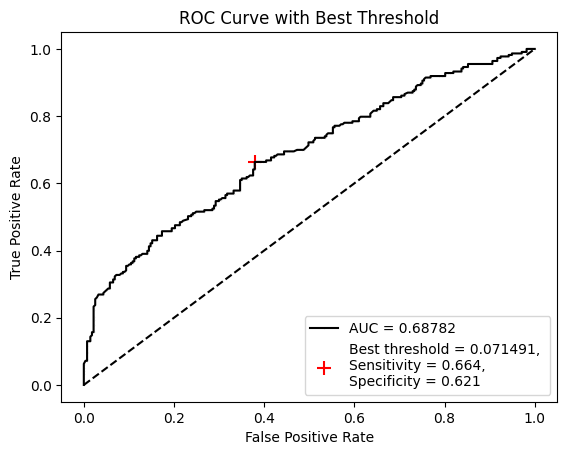

In [ ]:
# 그래프 1개에 대한 분석(perturbation)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, classification_report, roc_auc_score

# 데이터셋 로드 및 처리
# perturbation_original = pd.read_excel("OOD_Detection_15_transformation_rules-main/OOD_Detection-main/ood/ood/perturbation/epsilon2/epsilon(0.016).xlsx")
perturbation_original = pd.read_excel("OOD_Detection_15_transformation_rules-main/OOD_Detection-main/ood/dataset_split/goldset_new.xlsx")
perturbation_data = perturbation_original.copy()
# perturbation_data = perturbation_data.sort_values(by=['values'], ascending=False)
perturbation_data['OOD_roc_label'] = perturbation_data.apply(lambda row: 0 if row['OOD여부'] == 'O' else 1, axis=1)
perturbation_label = perturbation_data['OOD_roc_label'].tolist()
# perturbation_score = perturbation_data['values'].tolist()
perturbation_score = perturbation_data['per_score'].tolist()

# ROC 곡선 계산
per_fpr, per_tpr, thresholds = roc_curve(perturbation_label, perturbation_score)
per_roc_auc = auc(per_fpr, per_tpr)

# 최적 임계값 찾기
J = per_tpr - per_fpr
ix = np.argmax(J)
best_thresh = thresholds[ix]
sens, spec = per_tpr[ix], 1 - per_fpr[ix]

# 분류 보고서 생성
y_pred = (np.array(perturbation_score) >= best_thresh).astype(int)
print(classification_report(perturbation_label, y_pred, target_names=['normal', 'abnormal']))

# ROC 곡선 및 최적 임계값 표시
plt.figure()
plt.plot([0, 1], [0, 1], linestyle='--', color='black')  # 대각선
plt.plot(per_fpr, per_tpr, marker='.', color='black', markersize=0.05, label="AUC = %.5f" % per_roc_auc)
plt.scatter(per_fpr[ix], per_tpr[ix], marker='+', s=100, color='red',
            label='Best threshold = %.6f, \nSensitivity = %.3f, \nSpecificity = %.3f' % (best_thresh, sens, spec))

# 축 레이블 및 범례
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc=4)
plt.title('ROC Curve with Best Threshold')
plt.show()


              precision    recall  f1-score   support

      normal       0.66      0.83      0.73       277
    abnormal       0.68      0.46      0.55       223

    accuracy                           0.66       500
   macro avg       0.67      0.64      0.64       500
weighted avg       0.67      0.66      0.65       500



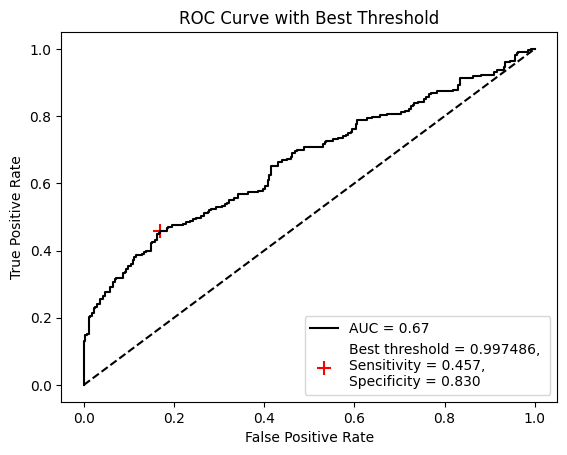

In [ ]:
# 그래프 1개에 대한 분석(msp)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, classification_report, roc_auc_score

# 첫 번째 데이터셋 로드 및 처리 # GOLDSET(MSP)
goldset_original = pd.read_excel("OOD_Detection_15_transformation_rules-main/OOD_Detection-main/ood/dataset_split/goldset_new.xlsx")
gs_roc_curve_data = goldset_original.copy()
# gs_roc_curve_data = gs_roc_curve_data.sort_values(by=['MSP_score'], ascending=False)
gs_roc_curve_data['OOD_roc_label'] = gs_roc_curve_data.apply(lambda row: 0 if row['OOD여부'] == 'O' else 1, axis=1)
gs_list_from_roc_label = gs_roc_curve_data['OOD_roc_label'].tolist()
gs_list_from_score = gs_roc_curve_data['msp_wo_ts_score'].tolist()

# ROC 곡선 계산
gs_fpr, gs_tpr, thresholds = roc_curve(gs_list_from_roc_label, gs_list_from_score)
gs_roc_auc = auc(gs_fpr, gs_tpr)

# 최적 임계값 찾기
J = gs_tpr - gs_fpr
ix = np.argmax(J)
best_thresh = thresholds[ix]
sens, spec = gs_tpr[ix], 1 - gs_fpr[ix]

# 분류 보고서 생성
y_pred = (np.array(gs_list_from_score) >= best_thresh).astype(int)
print(classification_report(gs_list_from_roc_label, y_pred, target_names=['normal', 'abnormal']))

# ROC 곡선 및 최적 임계값 표시
plt.figure()
plt.plot([0, 1], [0, 1], linestyle='--', color='black')  # 대각선
plt.plot(gs_fpr, gs_tpr, marker='.', color='black', markersize=0.05, label="AUC = %.2f" % gs_roc_auc)
plt.scatter(gs_fpr[ix], gs_tpr[ix], marker='+', s=100, color='red',
            label='Best threshold = %.6f, \nSensitivity = %.3f, \nSpecificity = %.3f' % (best_thresh, sens, spec))

# 축 레이블 및 범례
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc=4)
plt.title('ROC Curve with Best Threshold')
plt.show()


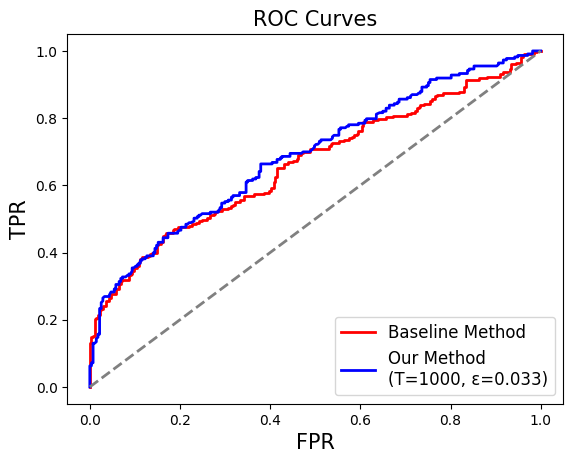

In [ ]:
# msp와 perturbation 한 값 두 그래프만 비교
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, classification_report, roc_auc_score

# 첫 번째 데이터셋 (perturbation_data) 로드 및 처리
perturbation_original = pd.read_excel("OOD_Detection_15_transformation_rules-main/OOD_Detection-main/ood/dataset_split/goldset_new.xlsx")
perturbation_data = perturbation_original.copy()
# perturbation_data = perturbation_data.sort_values(by=['values'], ascending=False)
perturbation_data['OOD_roc_label'] = perturbation_data.apply(lambda row: 0 if row['OOD여부'] == 'O' else 1, axis=1)
perturbation_label = perturbation_data['OOD_roc_label'].tolist()
perturbation_score = perturbation_data['per_score'].tolist()

# 두 번째 데이터셋 (goldset_data) 로드 및 처리
goldset_original = pd.read_excel("OOD_Detection_15_transformation_rules-main/OOD_Detection-main/ood/dataset_split/goldset_new.xlsx")
gs_roc_curve_data = goldset_original.copy()
# gs_roc_curve_data = gs_roc_curve_data.sort_values(by=['MSP_score'], ascending=False)
gs_roc_curve_data['OOD_roc_label'] = gs_roc_curve_data.apply(lambda row: 0 if row['OOD여부'] == 'O' else 1, axis=1)
gs_list_from_roc_label = gs_roc_curve_data['OOD_roc_label'].tolist()
gs_list_from_score = gs_roc_curve_data['msp_wo_ts_score'].tolist()

# ROC 곡선 및 AUC 계산 (perturbation_data)
per_fpr, per_tpr, _ = roc_curve(perturbation_label, perturbation_score)
per_roc_auc = auc(per_fpr, per_tpr)

# ROC 곡선 및 AUC 계산 (goldset_data)
gs_fpr, gs_tpr, _ = roc_curve(gs_list_from_roc_label, gs_list_from_score)
gs_roc_auc = auc(gs_fpr, gs_tpr)

# ROC 곡선 플로팅
plt.figure()
# plt.plot(per_fpr, per_tpr, color='blue', lw=2, label='MSP + T.S + I.P' % per_roc_auc)
# plt.plot(gs_fpr, gs_tpr, color='red', lw=2, label='Baseline(MSP)' % gs_roc_auc)
plt.plot(gs_fpr, gs_tpr, color='red', lw=2, label='Baseline Method' % gs_roc_auc)
plt.plot(per_fpr, per_tpr, color='blue', lw=2, label='Our Method\n(T=1000, ε=0.033)' % per_roc_auc)
plt.plot([0, 1], [0, 1], color='grey', lw=2, linestyle='--')

# 축 레이블 및 범례
plt.xlabel('FPR', fontsize=15)
plt.ylabel('TPR', fontsize=15)
plt.title('ROC Curves', fontsize=15)
plt.legend(loc="lower right", fontsize=12)
plt.show()


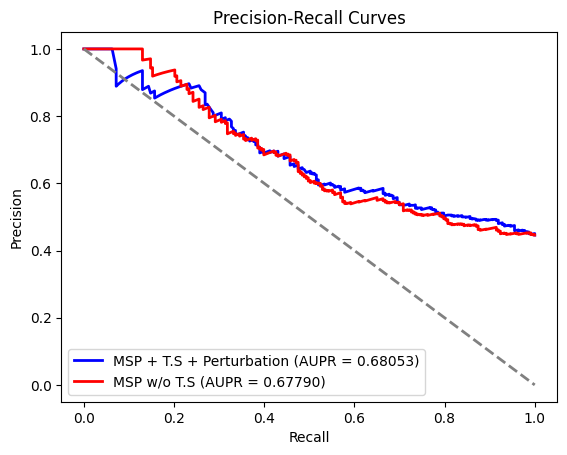

In [157]:
# AUPR 그래프
from sklearn.metrics import precision_recall_curve, auc

# Precision-Recall 곡선 및 AUPR 계산 (perturbation_data)
per_precision, per_recall, _ = precision_recall_curve(perturbation_label, perturbation_score)
per_aupr = auc(per_recall, per_precision)

# Precision-Recall 곡선 및 AUPR 계산 (goldset_data)
gs_precision, gs_recall, _ = precision_recall_curve(gs_list_from_roc_label, gs_list_from_score)
gs_aupr = auc(gs_recall, gs_precision)

# Precision-Recall 곡선 플로팅
plt.figure()
plt.plot(per_recall, per_precision, color='blue', lw=2, label='MSP + T.S + Perturbation (AUPR = %0.5f)' % per_aupr)
plt.plot(gs_recall, gs_precision, color='red', lw=2, label='MSP w/o T.S (AUPR = %0.5f)' % gs_aupr)
plt.plot([0, 1], [1, 0], color='grey', lw=2, linestyle='--')

# 축 레이블 및 범례
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves')
plt.legend(loc="lower left")
plt.show()

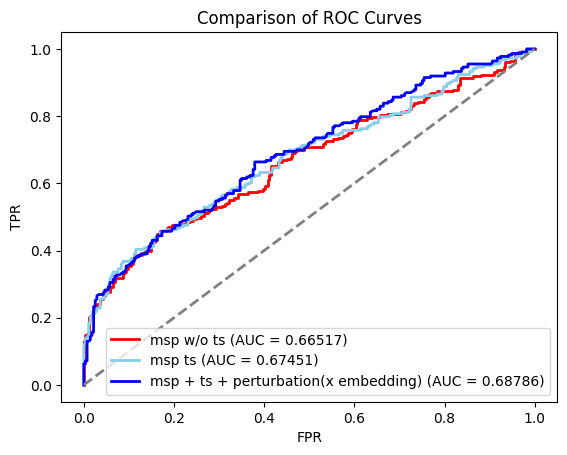

In [ ]:
# Best threshold 값 구하기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, roc_auc_score

# 첫 번째 데이터셋 (wo_ts) 로드 및 처리
msp_wo_ts_score_ori = pd.read_excel("OOD_Detection_15_transformation_rules-main/OOD_Detection-main/ood/dataset_split/goldset_new.xlsx")
msp_wo_ts_score_data = msp_wo_ts_score_ori.copy()
msp_wo_ts_score_data = msp_wo_ts_score_data.sort_values(by=['msp_wo_ts_score'], ascending=False)
msp_wo_ts_score_data['OOD_roc_label'] = msp_wo_ts_score_data.apply(lambda row: 0 if row['OOD여부'] == 'O' else 1, axis=1)
msp_wo_ts_label = msp_wo_ts_score_data['OOD_roc_label'].tolist()
msp_wo_ts_score = msp_wo_ts_score_data['msp_wo_ts_score'].tolist()

# 두 번째 데이터셋 (ts) 로드 및 처리
msp_ts_score_ori = pd.read_excel("OOD_Detection_15_transformation_rules-main/OOD_Detection-main/ood/dataset_split/goldset_new.xlsx")
msp_ts_score_data = msp_ts_score_ori.copy()
# msp_ts_score_data = msp_ts_score_data.sort_values(by=['msp_ts_score'], ascending=False)
msp_ts_score_data['OOD_roc_label'] = msp_ts_score_data.apply(lambda row: 0 if row['OOD여부'] == 'O' else 1, axis=1)
msp_ts_score_data_label = msp_ts_score_data['OOD_roc_label'].tolist()
msp_ts_score_data_score = msp_ts_score_data['msp_ts700_score'].tolist()

# 세번째 데이터셋 (perturbation-word embedding) 로드 및 처리
per_ori = pd.read_excel("OOD_Detection_15_transformation_rules-main/OOD_Detection-main/ood/dataset_split/goldset_new.xlsx")
per_data = per_ori.copy()
# per_data = per_data.sort_values(by=['per_score'], ascending=False)
per_data['OOD_roc_label'] = per_data.apply(lambda row: 0 if row['OOD여부'] == 'O' else 1, axis=1)
per_label = per_data['OOD_roc_label'].tolist()
per_score = per_data['per_score'].tolist()


# 데이터셋에 대한 ROC 곡선 계산
wo_ts_fpr, wo_ts_tpr, wo_ts_thresholds = roc_curve(msp_wo_ts_label, msp_wo_ts_score)
ts_fpr, ts_tpr, ts_thresholds = roc_curve(msp_ts_score_data_label, msp_ts_score_data_score)
per_fpr, per_tpr, per_thresholds = roc_curve(per_label, per_score)

# 두 데이터셋에 대한 최적 임계값 찾기
wo_ts_J = wo_ts_tpr - wo_ts_fpr
wo_ts_ix = np.argmax(wo_ts_J)
wo_ts_best_thresh = wo_ts_thresholds[wo_ts_ix]

ts_J = ts_tpr - ts_fpr
ts_ix = np.argmax(ts_J)
ts_best_thresh = ts_thresholds[ts_ix]

per_J = per_tpr - per_fpr
per_ix = np.argmax(per_J)
per_best_thresh = per_thresholds[per_ix]


# 데이터셋에 대한 ROC 곡선 및 최적 임계값 표시
plt.figure()
plt.plot(wo_ts_fpr, wo_ts_tpr, color='red', lw=2, label='msp w/o ts (AUC = %.5f)' % auc(wo_ts_fpr, wo_ts_tpr))
# plt.plot(wo_ts_fpr, wo_ts_tpr, color='blue', lw=2, label='msp w/o ts')
# plt.scatter(per_fpr[per_ix], per_tpr[per_ix], marker='+', s=100, color='red',
#             label='Perturbation Best threshold = %.7f' % per_best_thresh)
# plt.scatter(wo_ts_fpr[wo_ts_ix], wo_ts_tpr[wo_ts_ix], marker='+', s=100, color='red')

plt.plot(ts_fpr, ts_tpr, color='skyblue', lw=2, label='msp ts (AUC = %.5f)' % auc(ts_fpr, ts_tpr))
# plt.plot(ts_fpr, ts_tpr, color='blue', lw=2, label='msp ts')
plt.plot(per_fpr, per_tpr, color='blue', lw=2, label='msp + ts + perturbation(x embedding) (AUC = %.5f)' % auc(per_fpr, per_tpr))
# plt.scatter(per_fpr[per_ix], per_tpr[per_ix], marker='+', s=100, color='black')

# plt.scatter(gs_fpr[gs_ix], gs_tpr[gs_ix], marker='+', s=100, color='purple')
# plt.scatter(gs_fpr[gs_ix], gs_tpr[gs_ix], marker='x', s=100, color='purple',
#             label='Goldset Best threshold = %.6f' % gs_best_thresh)
plt.plot([0, 1], [0, 1], color='grey', lw=2, linestyle='--')

# 축 레이블 및 범례
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('Comparison of ROC Curves')
plt.legend(loc="lower right")

plt.show()


In [2]:
# 93% TPR 일때의 FPR 과 성능차이
# TPR 값을 정의
specific_tpr_value = 0.93

# our method 데이터셋에 대해 가장 가까운 TPR 값을 찾고 해당하는 FPR 값을 얻기
per_nearest_index = np.argmin(np.abs(per_tpr - specific_tpr_value))
per_specific_fpr = per_fpr[per_nearest_index]


# baseline 데이터셋에 대해 가장 가까운 TPR 값을 찾고 해당하는 FPR 값을 얻기
wo_ts_nearest_index = np.argmin(np.abs(wo_ts_tpr - specific_tpr_value))
wo_ts_specific_fpr = wo_ts_fpr[wo_ts_nearest_index]

# 결과 출력
print("For TPR of {:.2f}:".format(specific_tpr_value))
print("baseline FPR: {:.3f}".format(wo_ts_specific_fpr))
print("our method FPR: {:.3f}".format(per_specific_fpr))


# 성능 차이 평가
performance_difference = abs(per_specific_fpr - wo_ts_specific_fpr)
performance_difference_percent = performance_difference*100
print("Performance difference: {:.2f}%".format(performance_difference_percent))

For TPR of 0.93:
Msp w/o T.S FPR: 0.910
Msp + T.S FPR: 0.856
Perturbation FPR: 0.801
Performance difference: 10.83%


In [3]:
# 95% TPR 일때의 FPR 과 성능차이
# TPR 값을 정의
specific_tpr_value = 0.95

# Perturbation 데이터셋에 대해 가장 가까운 TPR 값을 찾고 해당하는 FPR 값을 얻기
per_nearest_index = np.argmin(np.abs(per_tpr - specific_tpr_value))
per_specific_fpr = per_fpr[per_nearest_index]

# Goldset_ts 데이터셋에 대해 가장 가까운 TPR 값을 찾고 해당하는 FPR 값을 얻기
ts_nearest_index = np.argmin(np.abs(ts_tpr - specific_tpr_value))
ts_specific_fpr = ts_fpr[ts_nearest_index]

# Goldset 데이터셋에 대해 가장 가까운 TPR 값을 찾고 해당하는 FPR 값을 얻기
wo_ts_nearest_index = np.argmin(np.abs(wo_ts_tpr - specific_tpr_value))
wo_ts_specific_fpr = wo_ts_fpr[wo_ts_nearest_index]

# 결과 출력
print("For TPR of {:.2f}:".format(specific_tpr_value))
print("Msp w/o T.S FPR: {:.3f}".format(wo_ts_specific_fpr))
print("Msp + T.S FPR: {:.3f}".format(ts_specific_fpr))
print("Perturbation FPR: {:.3f}".format(per_specific_fpr))


# 성능 차이 평가
performance_difference = abs(per_specific_fpr - wo_ts_specific_fpr)
performance_difference_percent = performance_difference*100
print("Performance difference: {:.2f}%".format(performance_difference_percent))

For TPR of 0.95:
Msp w/o T.S FPR: 0.931
Msp + T.S FPR: 0.888
Perturbation FPR: 0.841
Performance difference: 9.03%


In [150]:
# TPR이 95% 일 때의 threshold
# Perturbation 데이터셋에 대해 TPR이 0.90에 가장 가까운 임계값
per_threshold_at_specific_tpr = per_thresholds[per_nearest_index]

# Goldset 데이터셋에 대해 TPR이 0.90에 가장 가까운 임계값
wo_ts_thresholds_at_specific_tpr = wo_ts_thresholds[wo_ts_nearest_index]

# 결과 출력
print("For TPR of {:.2f}:".format(specific_tpr_value))
print("Perturbation threshold at TPR 0.95: {:.10f}".format(per_threshold_at_specific_tpr))
print("Goldset threshold at TPR 0.95: {:.6f}".format(wo_ts_thresholds_at_specific_tpr))

For TPR of 0.93:
Perturbation threshold at TPR 0.95: 0.0714912700
Goldset threshold at TPR 0.95: 0.605132


In [160]:
# 90% precision 일 때의 threshold
from sklearn.metrics import precision_recall_curve

# our method 데이터셋에 대한 precision 계산
per_precision, per_recall, per_thresholds = precision_recall_curve(perturbation_label, perturbation_score)

# precision이 90%에 가장 가까운 임계값 찾기 (Perturbation)
per_closest_90_index = np.argmin(np.abs(per_precision - 0.95))
per_90_thresh = per_thresholds[per_closest_90_index]

# 결과 출력
print("Perturbation threshold for 90% precision: {:.9f}".format(per_90_thresh))

Goldset threshold for 95% precision: 0.99913850
Perturbation threshold for 95% precision: 0.071496430


In [152]:
# 최대 성능 차이
from scipy import interpolate

# 공통 TPR 값 생성
common_tpr = np.linspace(0, 1, 100)  # 0부터 1 사이를 100개의 점으로 나눔

# 보간을 사용하여 FPR 값을 동일한 TPR 값에 맞춤
interp_per_fpr = interpolate.interp1d(per_tpr, per_fpr, kind='nearest')(common_tpr)
interp_msp_wo_ts_fpr = interpolate.interp1d(wo_ts_tpr, wo_ts_fpr, kind='nearest')(common_tpr)

# FPR 차이 계산
fpr_differences = np.abs(interp_per_fpr - interp_msp_wo_ts_fpr)
max_diff_index = np.argmax(fpr_differences)
max_diff_tpr = common_tpr[max_diff_index]

# 결과 출력
print("Maximum performance difference at TPR: {:.3f}".format(max_diff_tpr))
print("Perturbation FPR: {:.3f}".format(interp_per_fpr[max_diff_index]))
print("Goldset FPR: {:.3f}".format(interp_msp_wo_ts_fpr[max_diff_index]))
print("Performance difference: {:.3f}".format(fpr_differences[max_diff_index]))


Maximum performance difference at TPR: 0.889
Perturbation FPR: 0.736
Goldset FPR: 0.830
Performance difference: 0.094


In [ ]:
# linear combination test한 값들
combination_score = pd.read_excel("OOD_Detection_15_transformation_rules-main/OOD_Detection-main/ood/ood/linear_combination/combination_score.xlsx")
# combination_data = combination_score.copy()
combination_data_df = pd.DataFrame(combination_score)
combination_data_df['multiplied_score'] = combination_data_df['dropout_score'] * combination_data_df['perturbation_score']
combination_data_df['lc_dr1_per9'] = combination_data_df['dropout_score']*0.1+ combination_data_df['perturbation_score']*0.9
combination_data_df['lc_dr2_per8'] = combination_data_df['dropout_score']*0.2+ combination_data_df['perturbation_score']*0.8
combination_data_df['lc_dr3_per7'] = combination_data_df['dropout_score']*0.3+ combination_data_df['perturbation_score']*0.7
combination_data_df['lc_dr4_per6'] = combination_data_df['dropout_score']*0.4+ combination_data_df['perturbation_score']*0.6
combination_data_df['lc_dr5_per5'] = combination_data_df['dropout_score']*0.5+ combination_data_df['perturbation_score']*0.5
combination_data_df['lc_dr6_per4'] = combination_data_df['dropout_score']*0.6+ combination_data_df['perturbation_score']*0.4
combination_data_df['lc_dr7_per3'] = combination_data_df['dropout_score']*0.7+ combination_data_df['perturbation_score']*0.3
combination_data_df['lc_dr8_per2'] = combination_data_df['dropout_score']*0.8+ combination_data_df['perturbation_score']*0.2
combination_data_df['lc_dr9_per1'] = combination_data_df['dropout_score']*0.9+ combination_data_df['perturbation_score']*0.1
combination_data_df['test'] = combination_data_df['dropout_score']*0.98+ combination_data_df['perturbation_score']*0.02

combination_data_df

output_file_path = 'OOD_Detection_15_transformation_rules-main/OOD_Detection-main/ood/ood/linear_combination/com_score_list.xlsx'
combination_data_df.to_excel(output_file_path, index=False)